# Analyse Exploratoire

### Import des modules

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Analyse Exploratoire

In [4]:
building_consumption = pd.read_csv('../data/2016_Building_Energy_Benchmarking.csv')

In [5]:
# On regarde comment un batiment est défini dans ce jeu de données 
building_consumption.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [6]:
# On regarde le nombre de valeurs manquantes par colonne ainsi que leur type 
building_consumption.info()

<class 'pandas.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   str    
 3   PrimaryPropertyType              3376 non-null   str    
 4   PropertyName                     3376 non-null   str    
 5   Address                          3376 non-null   str    
 6   City                             3376 non-null   str    
 7   State                            3376 non-null   str    
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   str    
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   str    
 12  Latitude                       

#### TERMINER L'ANALYSE EXPLORATOIRE 

A réaliser : 
- Une analyse descriptive des données, y compris une explication du sens des colonnes gardées, des arguments derrière la suppression de lignes ou de colonnes, des statistiques descriptives et des visualisations pertinentes.

In [7]:
# Dimensions du jeu de données (lignes, colonnes)
print(f"Dimensions initiales : {building_consumption.shape}")

Dimensions initiales : (3376, 46)


In [8]:
# Lister toutes les colonnes pour repérer celles liées au type de bâtiment
print("Colonnes disponibles dans le jeu de données :")
print(building_consumption.columns.tolist())

Colonnes disponibles dans le jeu de données :
['OSEBuildingID', 'DataYear', 'BuildingType', 'PrimaryPropertyType', 'PropertyName', 'Address', 'City', 'State', 'ZipCode', 'TaxParcelIdentificationNumber', 'CouncilDistrictCode', 'Neighborhood', 'Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'ListOfAllPropertyUseTypes', 'LargestPropertyUseType', 'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA', 'YearsENERGYSTARCertified', 'ENERGYSTARScore', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)', 'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)', 'NaturalGas(kBtu)', 'DefaultData', 'Comments', 'ComplianceStatus', 'Outlier', 'TotalGHGEmissions', 'GHGEmissionsIntensity']


In [9]:
# Observer les valeurs uniques dans 'BuildingType'
print("\nRépartition de la colonne 'BuildingType' :")
print(building_consumption['BuildingType'].value_counts())


Répartition de la colonne 'BuildingType' :
BuildingType
NonResidential          1460
Multifamily LR (1-4)    1018
Multifamily MR (5-9)     580
Multifamily HR (10+)     110
SPS-District K-12         98
Nonresidential COS        85
Campus                    24
Nonresidential WA          1
Name: count, dtype: int64


In [10]:
# Liste des types non-résidentiels identifiés à l'action précédente
non_residential_types = [
    'NonResidential', 
    'SPS-District K-12', 
    'Nonresidential COS', 
    'Campus', 
    'Nonresidential WA'
]

In [11]:
# Filtrage
df_clean = building_consumption[building_consumption['BuildingType'].isin(non_residential_types)].copy()

In [12]:
# Traçabilité du volume de données avant / après
n_avant = len(building_consumption)
n_apres = len(df_clean)
print(f"Nombre initial de lignes : {n_avant}")
print(f"Nombre de lignes conservées (non-résidentiel) : {n_apres}")
print(f"Nombre de lignes supprimées : {n_avant - n_apres} ({((n_avant - n_apres) / n_avant) * 100:.1f}%)")

Nombre initial de lignes : 3376
Nombre de lignes conservées (non-résidentiel) : 1668
Nombre de lignes supprimées : 1708 (50.6%)


In [13]:
# Sélection des colonnes candidates pour la target
candidate_targets = [
    'SiteEnergyUse(kBtu)', 
    'SiteEnergyUseWN(kBtu)', 
    'SiteEUI(kBtu/sf)', 
    'SourceEUI(kBtu/sf)', 
    'TotalGHGEmissions'
]

### Analyse et sélection de la variable cible (Target)

**Définition :** Aux États-Unis, le kBtu sert d'unité commune standardisée pour additionner différentes sources d'énergie (électricité mesurée en kWh, gaz naturel mesuré en therms, et vapeur) dans un seul et même indicateur global.

Plusieurs colonnes du jeu de données mesurent la performance énergétique et environnementale des bâtiments :

* **`SiteEnergyUse(kBtu)`** : Consommation énergétique totale réelle mesurée sur site (toutes énergies confondues : électricité, gaz, vapeur).
* **`SiteEnergyUseWN(kBtu)`** : Consommation totale ajustée/normalisée selon les variations météorologiques (*Weather Normalized*).
* **`SiteEUI(kBtu/sf)`** : Intensité énergétique sur site par unité de surface ($\text{kBtu} / \text{sq ft}$).
* **`SourceEUI(kBtu/sf)`** : Intensité énergétique globale incluant les pertes de production et de transport de l'énergie.
* **`TotalGHGEmissions`** : Émissions totales de gaz à effet de serre (en tonnes métriques d'équivalent $\text{CO}_2$).

---
**Choix retenu :** **`SiteEnergyUseWN(kBtu)`** est sélectionnée comme cible principale. Ce choix permet de modéliser la performance énergétique intrinsèque et structurelle des bâtiments en s'affranchissant des anomalies climatiques spécifiques de l'année 2016.

In [14]:
# Affichage des statistiques descriptives
print("Statistiques descriptives des cibles candidates :")
print(df_clean[candidate_targets].describe().T[['count', 'mean', 'min', '50%', 'max']])

Statistiques descriptives des cibles candidates :
                        count          mean  min           50%           max
SiteEnergyUse(kBtu)    1666.0  8.437933e+06  0.0  2.554947e+06  8.739237e+08
SiteEnergyUseWN(kBtu)  1665.0  8.064790e+06  0.0  2.685146e+06  4.716139e+08
SiteEUI(kBtu/sf)       1665.0  7.215880e+01  0.0  5.190000e+01  8.344000e+02
SourceEUI(kBtu/sf)     1666.0  1.758299e+02  0.0  1.309500e+02  2.620000e+03
TotalGHGEmissions      1666.0  1.849733e+02 -0.8  4.958000e+01  1.687098e+04


In [15]:
# Vérification des valeurs manquantes
print("\nValeurs manquantes :")
print(df_clean[candidate_targets].isnull().sum())


Valeurs manquantes :
SiteEnergyUse(kBtu)      2
SiteEnergyUseWN(kBtu)    3
SiteEUI(kBtu/sf)         3
SourceEUI(kBtu/sf)       2
TotalGHGEmissions        2
dtype: int64


#### Analyse des statistiques descriptives de la cible

L'inspection descriptive de la colonne cible **`SiteEnergyUseWN(kBtu)`** met en évidence deux points critiques :

1. **Présence d'anomalies de mesure :** 
   - La valeur minimale est de **$0\text{ kBtu}$** (et $3$ valeurs manquantes `NaN` sont recensées).
   - Un bâtiment actif ne pouvant pas avoir une consommation nulle, ces lignes correspondent à des compteurs inactifs ou des bâtiments inoccupés et doivent être retirées pour ne pas fausser l'apprentissage.

2. **Forte asymétrie de distribution (*right-skewed*) :**
   - La médiane ($2{,}68 \times 10^6\text{ kBtu}$) est très inférieure à la moyenne ($8{,}06 \times 10^6\text{ kBtu}$).
   - L'écart avec le maximum ($471{,}61 \times 10^6\text{ kBtu}$) indique une forte concentration sur les petites/moyennes consommations et une traîne vers la droite due à quelques très grands complexes.

---
**Décision :** Suppression des lignes ayant une cible manquante ou inférieure/égale à $0$ avant de poursuivre l'exploration.

In [16]:
# Suivi avant suppression
n_avant_cible = len(df_clean)

# Filtrage des consommations normalisées strictement positives
df_clean = df_clean[df_clean['SiteEnergyUseWN(kBtu)'].notnull() & (df_clean['SiteEnergyUseWN(kBtu)'] > 0)].copy()

# Traçabilité
n_apres_cible = len(df_clean)
print(f"Nombre de lignes avant nettoyage de la cible : {n_avant_cible}")
print(f"Nombre de lignes conservées (cible > 0) : {n_apres_cible}")
print(f"Lignes supprimées (nulles ou NaN) : {n_avant_cible - n_apres_cible}")

Nombre de lignes avant nettoyage de la cible : 1668
Nombre de lignes conservées (cible > 0) : 1640
Lignes supprimées (nulles ou NaN) : 28


#### Analyse des valeurs manquantes par colonne

Afin de ne pas perdre de données en supprimant aveuglément des lignes, nous évaluons le taux de valeurs manquantes (*NaN*) pour chaque colonne du jeu de données filtré.

**Objectifs de cette analyse :**
* Identifier les colonnes quasi vides (ex. > 50 % ou 90 % de valeurs manquantes) qui ne pourront pas être imputées de manière fiable.
* Comprendre l'origine métier des valeurs manquantes (ex. usages secondaires ou tertiaires inexistants pour un bâtiment à usage unique).
* Déterminer quelles colonnes écarter en amont afin de préserver un volume maximal de bâtiments pour l'entraînement des modèles.

In [17]:
# 1. Calcul du nombre et du pourcentage de valeurs manquantes
missing_counts = df_clean.isnull().sum()
missing_pct = (missing_counts / len(df_clean)) * 100

# 2. Création d'un DataFrame récapitulatif trié
missing_df = pd.DataFrame({
    'Valeurs Manquantes': missing_counts,
    'Pourcentage (%)': missing_pct.round(2)
})

# 3. Affichage des colonnes ayant au moins une valeur manquante
print("Colonnes présentant des valeurs manquantes :")
print(missing_df[missing_df['Valeurs Manquantes'] > 0].sort_values(by='Pourcentage (%)', ascending=False))

Colonnes présentant des valeurs manquantes :
                                 Valeurs Manquantes  Pourcentage (%)
Comments                                       1640           100.00
Outlier                                        1623            98.96
YearsENERGYSTARCertified                       1544            94.15
ThirdLargestPropertyUseType                    1288            78.54
ThirdLargestPropertyUseTypeGFA                 1288            78.54
SecondLargestPropertyUseType                    790            48.17
SecondLargestPropertyUseTypeGFA                 790            48.17
ENERGYSTARScore                                 554            33.78
ZipCode                                          16             0.98
LargestPropertyUseTypeGFA                         4             0.24
LargestPropertyUseType                            4             0.24


#### Sélection des variables et suppression des colonnes non pertinentes

Nous nettoyons les colonnes du jeu de données selon 3 critères :
1. **Métadonnées et identifiants :** Informations administratives ou textuelles non généralisables (`OSEBuildingID`, `Address`, `Comments`, etc.).
2. **Colonnes trop lacunaires :** Usages secondaires/tertiaires et certifications peu renseignées.
3. **Fuite d'information (*Data Leakage*) :** Sous-consommations détaillées (électricité, gaz) et intensités énergétiques calculées à partir de la cible.

In [18]:
# Liste des colonnes à écarter
cols_to_drop = [
    # Métadonnées & Identifiants
    'OSEBuildingID', 'DataYear', 'PropertyName', 'Address', 'City', 'State', 
    'TaxParcelIdentificationNumber', 'Comments', 'Outlier', 'YearsENERGYSTARCertified',
    # Usages secondaires/tertiaires très incomplets
    'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA',
    'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA',
    # Sous-consommations et métriques dérivées (Data Leakage)
    'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)', 'NaturalGas(kBtu)', 
    'SteamUse(kBtu)', 'SiteEnergyUse(kBtu)', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)', 
    'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)'
]

# Suppression des colonnes
df_model = df_clean.drop(columns=[c for c in cols_to_drop if c in df_clean.columns]).copy()

print(f"Nombre de colonnes initiales : {df_clean.shape[1]}")
print(f"Nombre de colonnes restantes pour l'analyse : {df_model.shape[1]}")
print("\nColonnes conservées :")
print(df_model.columns.tolist())

Nombre de colonnes initiales : 46
Nombre de colonnes restantes pour l'analyse : 22

Colonnes conservées :
['BuildingType', 'PrimaryPropertyType', 'ZipCode', 'CouncilDistrictCode', 'Neighborhood', 'Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'ListOfAllPropertyUseTypes', 'LargestPropertyUseType', 'LargestPropertyUseTypeGFA', 'ENERGYSTARScore', 'SiteEnergyUseWN(kBtu)', 'DefaultData', 'ComplianceStatus', 'TotalGHGEmissions', 'GHGEmissionsIntensity']


#### Visualisation de la distribution de la variable cible

Nous comparons la distribution brute de `SiteEnergyUseWN(kBtu)` avec sa transformation logarithmique `log1p` :
* **Distribution brute :** Permet d'observer l'étalement réel des valeurs et l'écrasement visuel provoqué par les très grands bâtiments.
* **Transformation Log :** Permet de stabiliser la variance et de vérifier si la cible adopte une forme en cloche plus symétrique, idéale pour les algorithmes d'apprentissage supervisé.

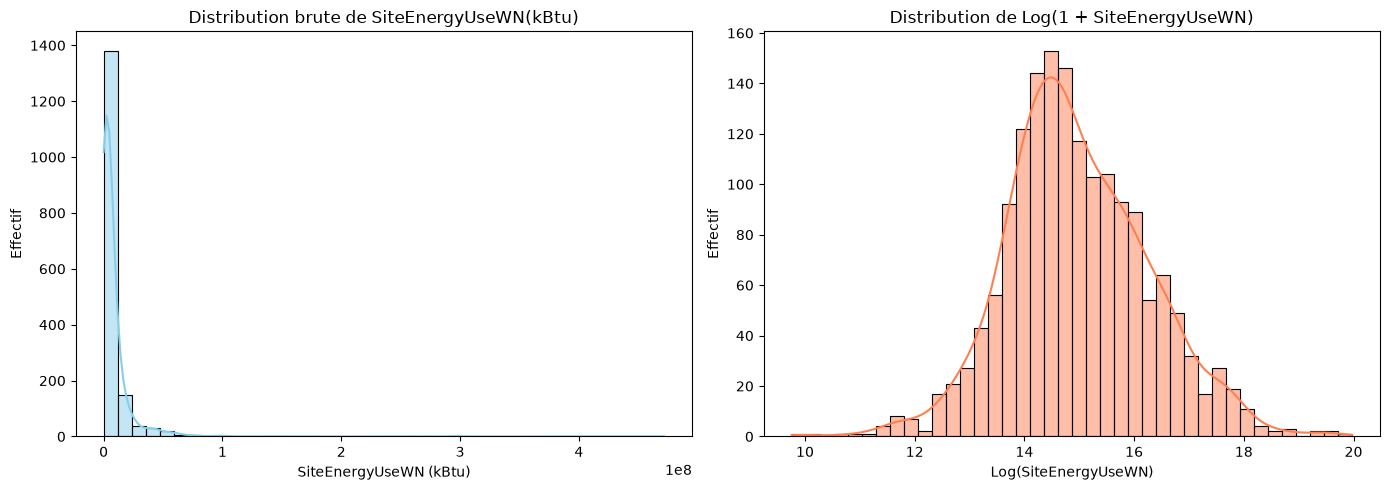

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Distribution brute
sns.histplot(df_model['SiteEnergyUseWN(kBtu)'], bins=40, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title("Distribution brute de SiteEnergyUseWN(kBtu)")
axes[0].set_xlabel("SiteEnergyUseWN (kBtu)")
axes[0].set_ylabel("Effectif")

# 2. Distribution transformée en Logarithme
sns.histplot(np.log1p(df_model['SiteEnergyUseWN(kBtu)']), bins=40, kde=True, ax=axes[1], color='coral')
axes[1].set_title("Distribution de Log(1 + SiteEnergyUseWN)")
axes[1].set_xlabel("Log(SiteEnergyUseWN)")
axes[1].set_ylabel("Effectif")

plt.tight_layout()
plt.show()

In [20]:
# Calcul mathématique des coefficients d'asymétrie (Skewness)
skew_brute = df_model['SiteEnergyUseWN(kBtu)'].skew()
skew_log = np.log1p(df_model['SiteEnergyUseWN(kBtu)']).skew()

print(f"Skewness de la cible brute : {skew_brute:.2f}")
print(f"Skewness de la cible transformée en log : {skew_log:.2f}")

Skewness de la cible brute : 11.24
Skewness de la cible transformée en log : 0.22


#### Interprétation de la distribution de la cible

* **Distribution brute :** Présente une très forte asymétrie à droite (*skewness* de $11{,}24$). Les valeurs extrêmes écrasent les données et risquent de biaiser l'apprentissage des modèles.
* **Distribution Log :** Le passage au logarithme $\log(1 + \text{SiteEnergyUseWN})$ régularise la distribution en une forme gaussienne symétrique (*skewness* de $0{,}22$). 

> **Décision :** La cible sera entraînée sous sa forme logarithmique $\log(1 + y)$ pour stabiliser la variance des résidus et améliorer les performances des algorithmes de régression.

#### Analyse bivariée : Relation Surface Totale vs Consommation Énergétique

Nous étudions le lien entre la dimension structurelle principale du bâtiment (**`PropertyGFATotal`** - Gross Floor Area totale) et sa consommation énergétique normalisée (**`SiteEnergyUseWN(kBtu)`**).

* **Échelle Log-Log :** Permet d'observer la linéarité du lien sur plusieurs ordres de grandeur de surfaces sans écrasement graphique.
* **Segmentation par type de bâtiment :** La couleur par **`BuildingType`** permet d'identifier des disparités d'intensité énergétique selon la catégorie du bien (ex. campus, écoles, bureaux standard).

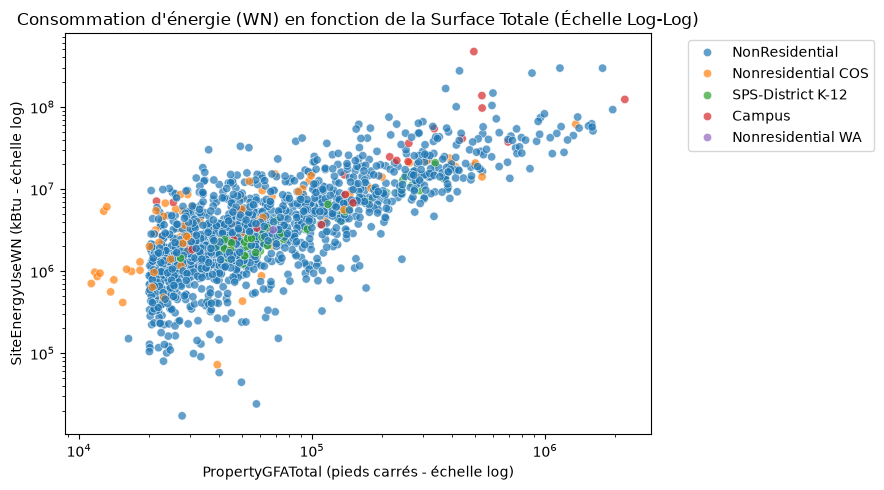

Coefficient de corrélation linéaire (Pearson) Surface Totale vs Cible brute : 0.59
Coefficient de corrélation linéaire (Pearson) Log(Surface) vs Log(Cible) : 0.76


In [21]:
plt.figure(figsize=(9, 5))

# Nuage de points en échelle Log-Log
sns.scatterplot(
    data=df_model, 
    x='PropertyGFATotal', 
    y='SiteEnergyUseWN(kBtu)', 
    hue='BuildingType', 
    alpha=0.7
)

plt.xscale('log')
plt.yscale('log')
plt.title("Consommation d'énergie (WN) en fonction de la Surface Totale (Échelle Log-Log)")
plt.xlabel("PropertyGFATotal (pieds carrés - échelle log)")
plt.ylabel("SiteEnergyUseWN (kBtu - échelle log)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Calcul du coefficient de corrélation linéaire (Pearson)
corr_surface = df_model['PropertyGFATotal'].corr(df_model['SiteEnergyUseWN(kBtu)'])
print(f"Coefficient de corrélation linéaire (Pearson) Surface Totale vs Cible brute : {corr_surface:.2f}")

# Corrélation sur les variables transformées en Log
corr_surface_log = np.log1p(df_model['PropertyGFATotal']).corr(np.log1p(df_model['SiteEnergyUseWN(kBtu)']))
print(f"Coefficient de corrélation linéaire (Pearson) Log(Surface) vs Log(Cible) : {corr_surface_log:.2f}")

#### Interprétation de la relation Surface Totale vs Consommation Énergétique

* **Corrélation linéaire forte en Log-Log ($r = 0{,}76$) :** La surface totale (`PropertyGFATotal`) constitue le premier déterminant mécanique de la consommation énergétique globale. La transformation logarithmique linéarise nettement cette relation (gain de $0{,}59$ à $0{,}76$).
* **Dispersion à surface équivalente :** L'étalement vertical pour une même taille de bâtiment met en évidence l'impact majeur d'autres facteurs (type d'activité, intensité d'usage, année de construction, mix d'équipements).

> **Conclusion :** `PropertyGFATotal` est une feature clé incontournable, mais elle doit être complétée par les caractéristiques d'usage et d'âge du bâtiment pour une prédiction précise.

#### Analyse bivariée : Influence de l'usage principal (PrimaryPropertyType) sur la consommation

Nous étudions l'impact du type d'activité du bâtiment (**`PrimaryPropertyType`**) sur la consommation énergétique (**`SiteEnergyUseWN(kBtu)`**)
* **Boîtes à moustaches (Boxplots) :** Permettent de comparer la médiane, l'écart interquartile (dispersion) et les ordres de grandeur de consommation pour chaque catégorie d'usage.
* **Échelle logarithmique :** Utilisée pour visualiser l'ensemble des catégories sans écrasement par les plus gros complexes.
* **Tri par médiane :** Les types de propriétés sont ordonnés de manière croissante selon leur niveau de consommation médian.

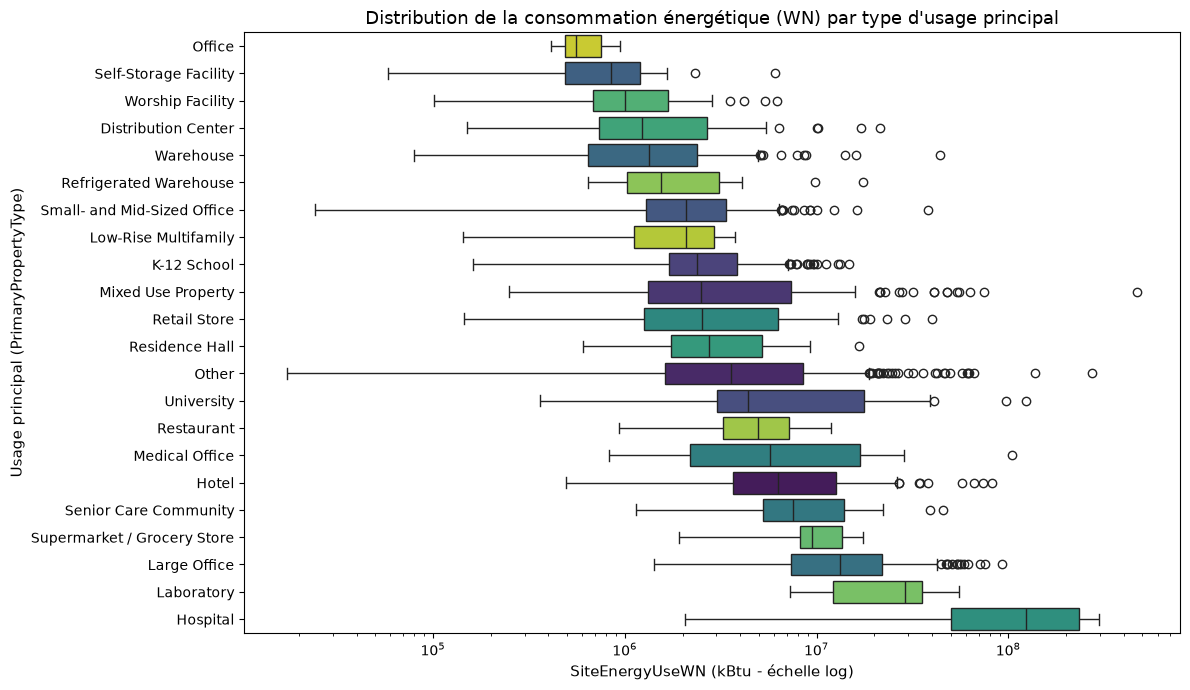

In [22]:
plt.figure(figsize=(12, 7))

# Ordonner les types d'usage selon la médiane de consommation
order_types = df_model.groupby('PrimaryPropertyType')['SiteEnergyUseWN(kBtu)'].median().sort_values().index

# Tracé sans warning
sns.boxplot(
    data=df_model,
    y='PrimaryPropertyType',
    x='SiteEnergyUseWN(kBtu)',
    order=order_types,
    hue='PrimaryPropertyType',
    palette='viridis',
    legend=False
)

plt.xscale('log')
plt.title("Distribution de la consommation énergétique (WN) par type d'usage principal", fontsize=13)
plt.xlabel("SiteEnergyUseWN (kBtu - échelle log)", fontsize=11)
plt.ylabel("Usage principal (PrimaryPropertyType)", fontsize=11)

plt.tight_layout()
plt.show()

#### Interprétation : Influence du type d'usage principal (PrimaryPropertyType)

* **Gradient de consommation marqué :** La médiane de consommation varie de plus de deux ordres de grandeur (d'environ $8 \times 10^5\text{ kBtu}$ pour les entrepôts/lieux de culte à plus de $10^8\text{ kBtu}$ pour les hôpitaux).
* **Intensité d'exploitation :** Les établissements fonctionnant en continu avec des équipements techniques lourds (*Hospital*, *Laboratory*, *Supermarket*, *Large Office*) présentent les consommations les plus élevées.
* **Hétérogénéité intra-catégorie :** La dispersion au sein des catégories mixtes ou hôtelières reflète des différences importantes de surface et d'occupation.

> **Décision :** La variable `PrimaryPropertyType` est un prédicteur catégoriel majeur qui devra être intégré et encodé dans notre pipeline de modélisation.

#### Matrice de corrélation des variables numériques

Nous calculons la matrice des corrélations linéaires (Pearson) entre les variables quantitatives physiques (`PropertyGFATotal`, `PropertyGFABuilding(s)`, `PropertyGFAParking`, `LargestPropertyUseTypeGFA`, `NumberofFloors`, `NumberofBuildings`, `YearBuilt`), le score environnemental (`ENERGYSTARScore`) et la cible sous sa forme transformée ($\log(1 + \text{SiteEnergyUseWN})$).

**Objectifs :**
1. **Identifier les variables les plus corrélées à la cible.**
2. **Repérer les redondances (multicollinéarité) entre les différentes mesures de surface.**

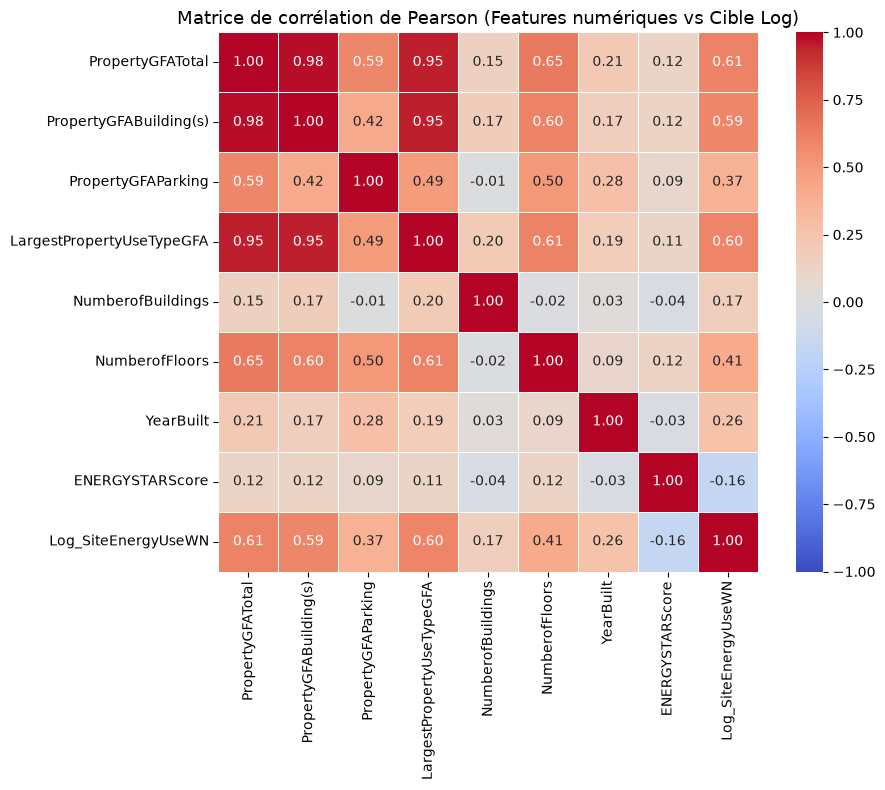

In [23]:
# 1. Sélection des features numériques d'intérêt + cible log
df_corr = df_model[[
    'PropertyGFATotal', 
    'PropertyGFABuilding(s)', 
    'PropertyGFAParking', 
    'LargestPropertyUseTypeGFA', 
    'NumberofBuildings', 
    'NumberofFloors', 
    'YearBuilt', 
    'ENERGYSTARScore'
]].copy()

# Ajout de la cible en échelle Log
df_corr['Log_SiteEnergyUseWN'] = np.log1p(df_model['SiteEnergyUseWN(kBtu)'])

# 2. Calcul de la matrice de corrélation
corr_matrix = df_corr.corr()

# 3. Tracé de la Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    square=True, 
    linewidths=0.5
)

plt.title("Matrice de corrélation de Pearson (Features numériques vs Cible Log)", fontsize=13)
plt.tight_layout()
plt.show()

#### Interprétation de la matrice de corrélation des variables numériques

1. **Variables les plus corrélées à la cible (`Log_SiteEnergyUseWN`) :**
   * **Dimensions physiques globales :** `PropertyGFATotal` ($r = 0{,}61$), `LargestPropertyUseTypeGFA` ($r = 0{,}60$) et `PropertyGFABuilding(s)` ($r = 0{,}59$) présentent les plus fortes corrélations linéaires positives avec la consommation d'énergie.
   * **Hauteur du bâtiment :** `NumberofFloors` affiche une corrélation modérée positive ($r = 0{,}41$).
   * **Surfaces annexes et âge :** `PropertyGFAParking` ($r = 0{,}37$) et `YearBuilt` ($r = 0{,}26$) ont un lien modéré avec la cible.
   * **Performance énergétique :** `ENERGYSTARScore` présente une corrélation négative faible ($r = -0{,}16$), cohérente avec le métier (un score plus élevé reflète une meilleure efficacité énergétique).

2. **Mise en évidence de la multicollinéarité (redondances) :**
   * Les différentes mesures de surface sont quasi parfaitement corrélées entre elles ($r \ge 0{,}95$) :
     * `PropertyGFATotal` $\leftrightarrow$ `PropertyGFABuilding(s)` : $r = 0{,}98$
     * `PropertyGFATotal` $\leftrightarrow$ `LargestPropertyUseTypeGFA` : $r = 0{,}95$
     * `PropertyGFABuilding(s)` $\leftrightarrow$ `LargestPropertyUseTypeGFA` : $r = 0{,}95$

> **Décision pour la modélisation :**
> * Afin d'éviter l'instabilité des modèles linéaires liée à la multicollinéarité, nous conserverons une mesure de surface de référence (`PropertyGFATotal`) et pourrons transformer les autres en ratios (ex. proportion de surface de parking).
> * Les modèles à base d'arbres (*Random Forest*, *XGBoost*) seront particulièrement adaptés pour capter les relations non linéaires avec `YearBuilt` et `ENERGYSTARScore`.

#### Analyse exploratoire de la seconde cible : TotalGHGEmissions (Émissions de GES)

Nous explorons la distribution de la variable **`TotalGHGEmissions`** (exprimée en tonnes métriques d'équivalent CO2) ainsi que sa relation avec la surface totale (**`PropertyGFATotal`**) :
1. **Distribution brute vs transformée en log ($\log(1+y)$) :** Vérification de l'asymétrie et du comportement de la distribution.
2. **Corrélation et nuage de points Log-Log :** Mesure du lien entre la surface et les émissions de GES.

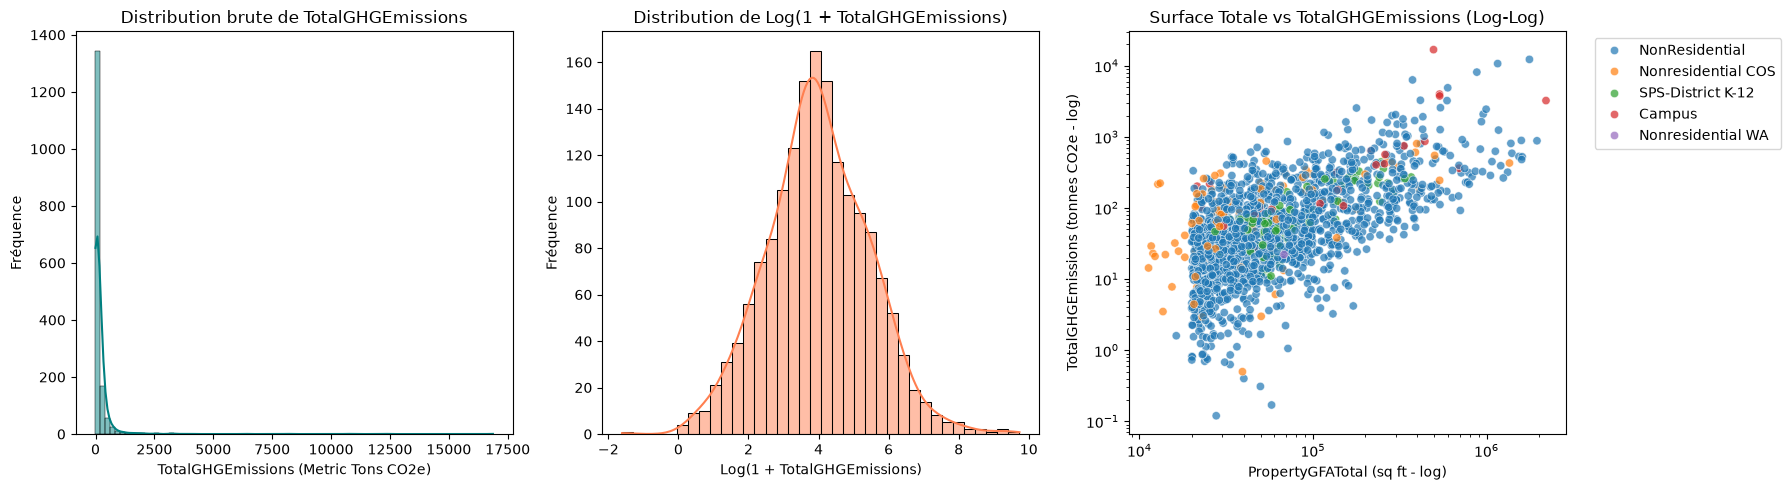

Corrélation linéaire Surface vs TotalGHGEmissions (brute) : 0.42
Corrélation linéaire Log(Surface) vs Log(TotalGHGEmissions) : 0.61


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histogramme de la distribution brute
sns.histplot(df_model['TotalGHGEmissions'], kde=True, ax=axes[0], color='teal')
axes[0].set_title("Distribution brute de TotalGHGEmissions")
axes[0].set_xlabel("TotalGHGEmissions (Metric Tons CO2e)")
axes[0].set_ylabel("Fréquence")

# 2. Histogramme après transformation Logarithmique
log_ghg = np.log1p(df_model['TotalGHGEmissions'])
sns.histplot(log_ghg, kde=True, ax=axes[1], color='coral')
axes[1].set_title("Distribution de Log(1 + TotalGHGEmissions)")
axes[1].set_xlabel("Log(1 + TotalGHGEmissions)")
axes[1].set_ylabel("Fréquence")

# 3. Nuage de points Log-Log (Surface vs Émissions GHG)
sns.scatterplot(
    data=df_model, 
    x='PropertyGFATotal', 
    y='TotalGHGEmissions', 
    hue='BuildingType', 
    alpha=0.7,
    ax=axes[2]
)
axes[2].set_xscale('log')
axes[2].set_yscale('log')
axes[2].set_title("Surface Totale vs TotalGHGEmissions (Log-Log)")
axes[2].set_xlabel("PropertyGFATotal (sq ft - log)")
axes[2].set_ylabel("TotalGHGEmissions (tonnes CO2e - log)")
axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Corrélations de Pearson
corr_ghg_raw = df_model['PropertyGFATotal'].corr(df_model['TotalGHGEmissions'])
corr_ghg_log = np.log1p(df_model['PropertyGFATotal']).corr(log_ghg)

print(f"Corrélation linéaire Surface vs TotalGHGEmissions (brute) : {corr_ghg_raw:.2f}")
print(f"Corrélation linéaire Log(Surface) vs Log(TotalGHGEmissions) : {corr_ghg_log:.2f}")

#### Interprétation de l'analyse exploratoire sur TotalGHGEmissions

* **Forte asymétrie à droite :** La distribution brute des émissions de GES est très étalée et dominée par quelques valeurs extrêmes.
* **Validation de la transformation logarithmique :** L'application de $\log(1+y)$ permet d'obtenir une distribution symétrique (proche d'une loi normale), indispensable pour stabiliser les résidus des modèles de régression.
* **Lien avec la surface, le mix énergétique et le type d'usage :** Bien que la surface totale soit corrélée positivement aux émissions, la grande dispersion verticale à surface égale s'explique par :
  1. **Le mix énergétique :** L'intensité carbone dépend du recours au gaz/vapeur par rapport à l'électricité (largement décarbonée à Seattle).
  2. **Le type d'usage du bâtiment (`PrimaryPropertyType`) :** Les activités à forte intensité continue ou nécessitant des procédés thermiques lourds (hôpitaux, restauration, hôtels) émettent nettement plus de GES à surface équivalente que des bureaux ou des entrepôts.

> **Conclusion :** Tout comme pour `SiteEnergyUseWN`, la cible `TotalGHGEmissions` devra être prédite sous sa forme logarithmique, et le type d'activité sera une variable explicative déterminante.

In [25]:
# ==============================================================================
# FINALISATION DU NETTOYAGE (EDA) : FILTRAGE ADMINISTRATIF & VALEURS ABERRANTES
# ==============================================================================

print(f"Nombre de lignes initial : {len(df_model)}")

# 1. Filtrage sur ComplianceStatus et Outlier (Indicateurs officiels)
# On ne conserve que les déclarations conformes (Compliant)
if 'ComplianceStatus' in df_model.columns:
    df_model = df_model[df_model['ComplianceStatus'].str.lower() == 'compliant']

# On retire les bâtiments étiquetés officiellement comme valeurs aberrantes
if 'Outlier' in df_model.columns:
    # On conserve les valeurs nulles (non-outliers) ou différentes de 'Outlier'
    df_model = df_model[df_model['Outlier'].isna() | (df_model['Outlier'] == '')]

print(f"Lignes après filtrage administratif (Compliance / Outlier) : {len(df_model)}")

# 2. Détection formelle des valeurs aberrantes via la méthode de l'IQR
# On applique l'IQR sur la cible normalisée en log (SiteEnergyUseWN) et sur la surface (PropertyGFATotal)
cols_for_outliers = ['SiteEnergyUseWN(kBtu)', 'PropertyGFATotal']

for col in cols_for_outliers:
    # Calcul des quartiles sur la transformation log pour respecter la normalité
    log_vals = np.log1p(df_model[col])
    Q1 = log_vals.quantile(0.25)
    Q3 = log_vals.quantile(0.75)
    IQR = Q3 - Q1
    
    # Bornes de Tukey (seuil standard 1.5 * IQR)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Masque de conservation
    mask_inliers = (log_vals >= lower_bound) & (log_vals <= upper_bound)
    outliers_count = (~mask_inliers).sum()
    print(f"Valeurs aberrantes détectées (IQR 1.5x sur log) pour '{col}' : {outliers_count}")
    
    # Filtrage
    df_model = df_model[mask_inliers]

print(f"\nDimensions finales du dataset assaini : {df_model.shape}")

Nombre de lignes initial : 1640
Lignes après filtrage administratif (Compliance / Outlier) : 1538
Valeurs aberrantes détectées (IQR 1.5x sur log) pour 'SiteEnergyUseWN(kBtu)' : 14
Valeurs aberrantes détectées (IQR 1.5x sur log) pour 'PropertyGFATotal' : 30

Dimensions finales du dataset assaini : (1494, 22)


#### Finalisation du filtrage des données (EDA)

1. **Filtrage administratif :**
   * Conservation exclusive des déclarations étiquetées `Compliant` dans `ComplianceStatus`.
   * Suppression des lignes catégorisées comme anomalies déclaratives dans la colonne `Outlier`.
2. **Détection statistique des valeurs aberrantes (Méthode IQR de Tukey) :**
   * Application de l'intervalle interquartile $[Q_1 - 1.5 \times \text{IQR}, Q_3 + 1.5 \times \text{IQR}]$ sur les distributions normalisées en $\log(1 + x)$ de `SiteEnergyUseWN(kBtu)` et `PropertyGFATotal`.
   * Ce filtrage élimine les points extrêmes résiduels sans tronquer la variabilité naturelle du parc immobilier.

# Modélisation 

### Import des modules 

In [26]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor


### Feature Engineering

A réaliser : Enrichir le jeu de données actuel avec de nouvelles features issues de celles existantes. 

### 1. Feature Engineering : Création de la variable `BuildingAge`

* **Calcul :** $\text{BuildingAge} = 2016 - \text{YearBuilt}$.
* **Justification métier :** 
  * L'année brute de construction (`YearBuilt`) est une date calendaire arbitraire.
  * Calculer l'ancienneté réelle par rapport à l'année de collecte (2016) donne une échelle physique positive (0 pour un bâtiment neuf en 2016), ce qui rend le coefficient du modèle directement interprétable (augmentation de l'usure et des déperditions thermiques avec l'âge).

In [27]:
# 1. Calcul de l'âge du bâtiment en 2016
df_model['BuildingAge'] = (2016 - df_model['YearBuilt']).clip(lower=0)

# Vérification descriptive
df_model[['YearBuilt', 'BuildingAge']].describe()

,YearBuilt,BuildingAge
count,1494.000000,1494.000000
mean,1961.161312,54.838688
std,32.852775,32.852775
min,1900.000000,1.000000
25%,1929.000000,28.000000
50%,1965.000000,51.000000
75%,1988.000000,87.000000
max,2015.000000,116.000000


### 2. Feature Engineering : Création de la variable `Parking_Ratio`

* **Calcul :** $\text{Parking\_Ratio} = \frac{\text{PropertyGFAParking}}{\text{PropertyGFATotal}}$ (borné entre 0 et 1).
* **Justification métier :** 
  * Les espaces de stationnement présentent une intensité énergétique négligeable par rapport aux espaces de bureaux ou commerces.
  * Ce ratio permet au modèle d'ajuster la consommation globale en fonction de la part de surface non chauffée/climatisée, tout en évitant la redondance avec la surface brute totale.

In [28]:
#  2. Calcul du ratio de surface de parking
if 'PropertyGFAParking' in df_model.columns and 'PropertyGFATotal' in df_model.columns:
    # Remplacement des zéros et NaN du dénominateur pour éviter les divisions par zéro
    parking_area = df_model['PropertyGFAParking'].fillna(0)
    total_area = df_model['PropertyGFATotal'].replace(0, np.nan)
    
    # Calcul avec gestion du clipping et remplissage des valeurs restantes à 0
    df_model['Parking_Ratio'] = (parking_area / total_area).clip(0, 1).fillna(0.0)
else:
    df_model['Parking_Ratio'] = 0.0

# Vérification descriptive
cols_to_check = [col for col in ['PropertyGFAParking', 'PropertyGFATotal', 'Parking_Ratio'] if col in df_model.columns]
print(df_model[cols_to_check].describe())

       PropertyGFAParking  PropertyGFATotal  Parking_Ratio
count         1494.000000       1494.000000    1494.000000
mean         11071.006024      90141.453146       0.064087
std          34121.198788     106946.127738       0.144135
min              0.000000      11285.000000       0.000000
25%              0.000000      28712.000000       0.000000
50%              0.000000      46645.000000       0.000000
75%              0.000000      99112.500000       0.000000
max         407795.000000     706176.000000       0.895023


### 3. Feature Engineering : Création de la variable `MainUse_Ratio`

* **Calcul :** $\text{MainUse\_Ratio} = \frac{\text{LargestPropertyUseTypeGFA}}{\text{PropertyGFATotal}}$ (borné entre 0 et 1).
* **Justification métier :** 
  * Évalue si le bâtiment est dédié à un usage unique ($\approx 1$) ou s'il s'agit d'un complexe mixte/hétérogène ($< 1$).
  * Évite d'injecter deux surfaces brutes redondantes dans les modèles tout en conservant l'information structurelle d'occupation.

In [29]:
# 3. Calcul du ratio d'usage principal
if 'LargestPropertyUseTypeGFA' in df_model.columns:
    df_model['MainUse_Ratio'] = (df_model['LargestPropertyUseTypeGFA'].fillna(0) / df_model['PropertyGFATotal']).clip(0, 1)
else:
    df_model['MainUse_Ratio'] = 1.0

# Vérification descriptive
df_model[['LargestPropertyUseTypeGFA', 'MainUse_Ratio']].describe()

,LargestPropertyUseTypeGFA,MainUse_Ratio
count,1490.00000,1494.000000
mean,73474.32349,0.830497
std,87315.35856,0.207640
min,5656.00000,0.000000
25%,24537.00000,0.667999
50%,40982.50000,0.942344
75%,85213.75000,1.000000
max,718473.00000,1.000000


### 4. Feature Engineering : Regroupement des modalités rares (`PrimaryPropertyType_Clean`)

* **Opération :** Regroupement sous le label `'Other'` des types de bâtiments représentant moins de 1 % de l'échantillon.
* **Justification métier :** Limite l'explosion dimensionnelle lors de l'encodage One-Hot et évite au modèle d'apprendre des règles statistiques fragiles sur des catégories anecdotiques.

In [30]:
# 4. Identification et regroupement des modalités rares (< 1% de l'échantillon)
threshold = 0.01 * len(df_model)
type_counts = df_model['PrimaryPropertyType'].value_counts()
rare_types = type_counts[type_counts < threshold].index

# Création de la variable nettoyée
df_model['PrimaryPropertyType_Clean'] = df_model['PrimaryPropertyType'].apply(
    lambda x: 'Other' if x in rare_types else x
)

# Affichage avant / après du nombre de modalités distinctes
n_before = df_model['PrimaryPropertyType'].nunique()
n_after = df_model['PrimaryPropertyType_Clean'].nunique()

print(f"Nombre de catégories avant regroupement : {n_before}")
print(f"Nombre de catégories après regroupement : {n_after}")
print("-" * 50)
print("Répartition finale des catégories :")
print(df_model['PrimaryPropertyType_Clean'].value_counts())

Nombre de catégories avant regroupement : 21
Nombre de catégories après regroupement : 16
--------------------------------------------------
Répartition finale des catégories :
PrimaryPropertyType_Clean
Small- and Mid-Sized Office    285
Other                          281
Warehouse                      182
Large Office                   146
Mixed Use Property             110
Retail Store                    84
Hotel                           72
Worship Facility                67
Distribution Center             53
K-12 School                     50
Supermarket / Grocery Store     40
Medical Office                  38
Self-Storage Facility           26
Residence Hall                  21
University                      20
Senior Care Community           19
Name: count, dtype: int64


### 5. Définition des variables explicatives ($X$) et des cibles ($y$)

* **Variables prédictives ($X$) :**
  * **Numériques :** `BuildingAge`, `NumberofBuildings`, `NumberofFloors`, `PropertyGFATotal`, `Parking_Ratio`, `MainUse_Ratio`, `Latitude`, `Longitude`.
  * **Catégorielles :** `BuildingType`, `PrimaryPropertyType_Clean`, `Neighborhood`, `CouncilDistrictCode`.
* **Cibles ($y$) en log(1+y) :**
  * Consommation d'énergie : `y_energy` = $\log(1 + \text{SiteEnergyUseWN(kBtu)})$
  * Émissions de GES : `y_ghg` = $\log(1 + \text{TotalGHGEmissions})$

In [31]:
import numpy as np

# 1. Listes des features explicatives
num_features = [
    'BuildingAge', 
    'NumberofBuildings', 
    'NumberofFloors', 
    'PropertyGFATotal', 
    'Parking_Ratio', 
    'MainUse_Ratio', 
    'Latitude', 
    'Longitude'
]

cat_features = [
    'BuildingType', 
    'PrimaryPropertyType_Clean', 
    'Neighborhood', 
    'CouncilDistrictCode'
]

# 2. Forcer le type chaîne de caractères pour les catégorielles
for col in cat_features:
    df_model[col] = df_model[col].astype(str)

# 3. Matrice des variables explicatives
X = df_model[num_features + cat_features].copy()

# 4. Définition des cibles transformées en log(1+y)
y_energy = np.log1p(df_model['SiteEnergyUseWN(kBtu)'])
y_ghg = np.log1p(df_model['TotalGHGEmissions'])

# 5. Contrôle des dimensions et des types
print(f"Dimensions de la matrice X : {X.shape}")
print(f"Dimensions de y_energy     : {y_energy.shape}")
print(f"Dimensions de y_ghg        : {y_ghg.shape}")
print("\nTypes des colonnes dans X :")
print(X.dtypes)

Dimensions de la matrice X : (1494, 12)
Dimensions de y_energy     : (1494,)
Dimensions de y_ghg        : (1494,)

Types des colonnes dans X :
BuildingAge                    int64
NumberofBuildings            float64
NumberofFloors                 int64
PropertyGFATotal               int64
Parking_Ratio                float64
MainUse_Ratio                float64
Latitude                     float64
Longitude                    float64
BuildingType                     str
PrimaryPropertyType_Clean        str
Neighborhood                     str
CouncilDistrictCode              str
dtype: object


### Préparation des features pour la modélisation

A réaliser :
* Si ce n'est pas déjà fait, supprimer toutes les colonnes peu pertinentes pour la modélisation.
* Tracer la distribution de la cible pour vous familiariser avec l'ordre de grandeur. En cas d'outliers, mettez en place une démarche pour les supprimer.
* Débarrassez-vous des features redondantes en utilisant une matrice de corrélation.
* Réalisez différents graphiques pour comprendre le lien entre vos features et la target (boxplots, scatterplots, pairplot si votre nombre de features numériques n'est pas très élevé).
*  Séparez votre jeu de données en un Pandas DataFrame X (ensemble de feautures) et Pandas Series y (votre target).
* Si vous avez des features catégorielles, il faut les encoder pour que votre modèle fonctionne.

### 1. Analyse de la multicolinéarité : Matrice de corrélation des features numériques

* **Objectif :** Vérifier l'absence de redondance stricte entre les variables explicatives numériques sélectionnées.
* **Méthode :** Matrice de corrélation linéaire de Pearson affichée sous forme de heatmap.

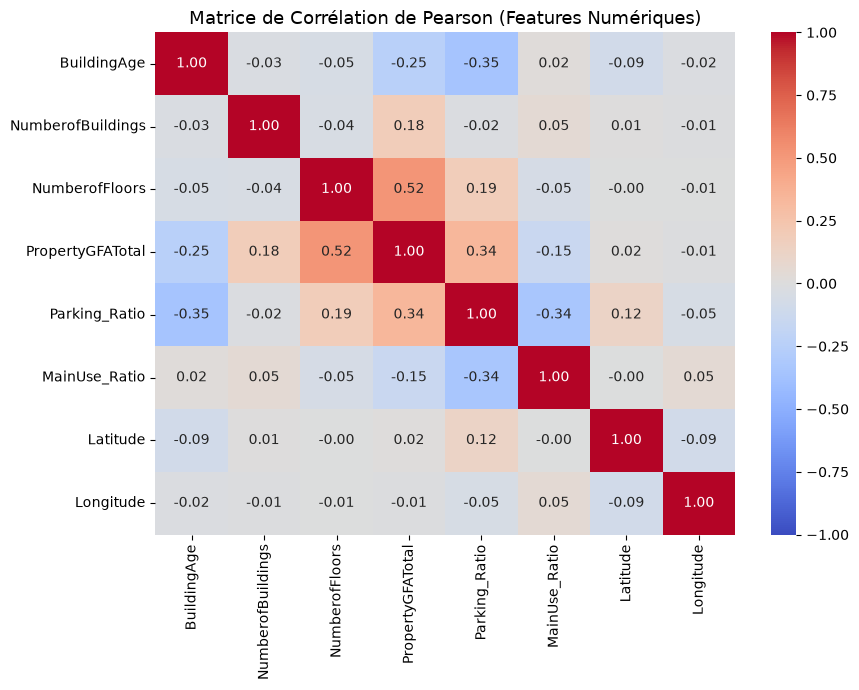

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Liste des features numériques retenues
num_cols = [
    'BuildingAge', 
    'NumberofBuildings', 
    'NumberofFloors', 
    'PropertyGFATotal', 
    'Parking_Ratio', 
    'MainUse_Ratio', 
    'Latitude', 
    'Longitude'
]

# Calcul de la matrice de corrélation de Pearson
corr_matrix = df_model[num_cols].corr()

# Affichage visuel (Heatmap)
plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, cbar=True)
plt.title("Matrice de Corrélation de Pearson (Features Numériques)", fontsize=13)
plt.tight_layout()
plt.show()

**Conclusion / Analyse :**
* Les corrélations entre les variables explicatives restent modérées ($|r| < 0.70$), ce qui confirme l'absence de redondance majeure ou de multicolinéarité critique entre les features numériques sélectionnées.

### 2. Analyse bivariée : Relations entre les features explicatives et la cible énergétique

* **Objectif :** Évaluer graphiquement l'impact des variables numériques (scatterplots) et catégorielles (boxplots) sur la consommation d'énergie transformée en log (`log_SiteEnergyUseWN`).

C:\Users\mahmo\AppData\Local\Temp\ipykernel_30160\885642395.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


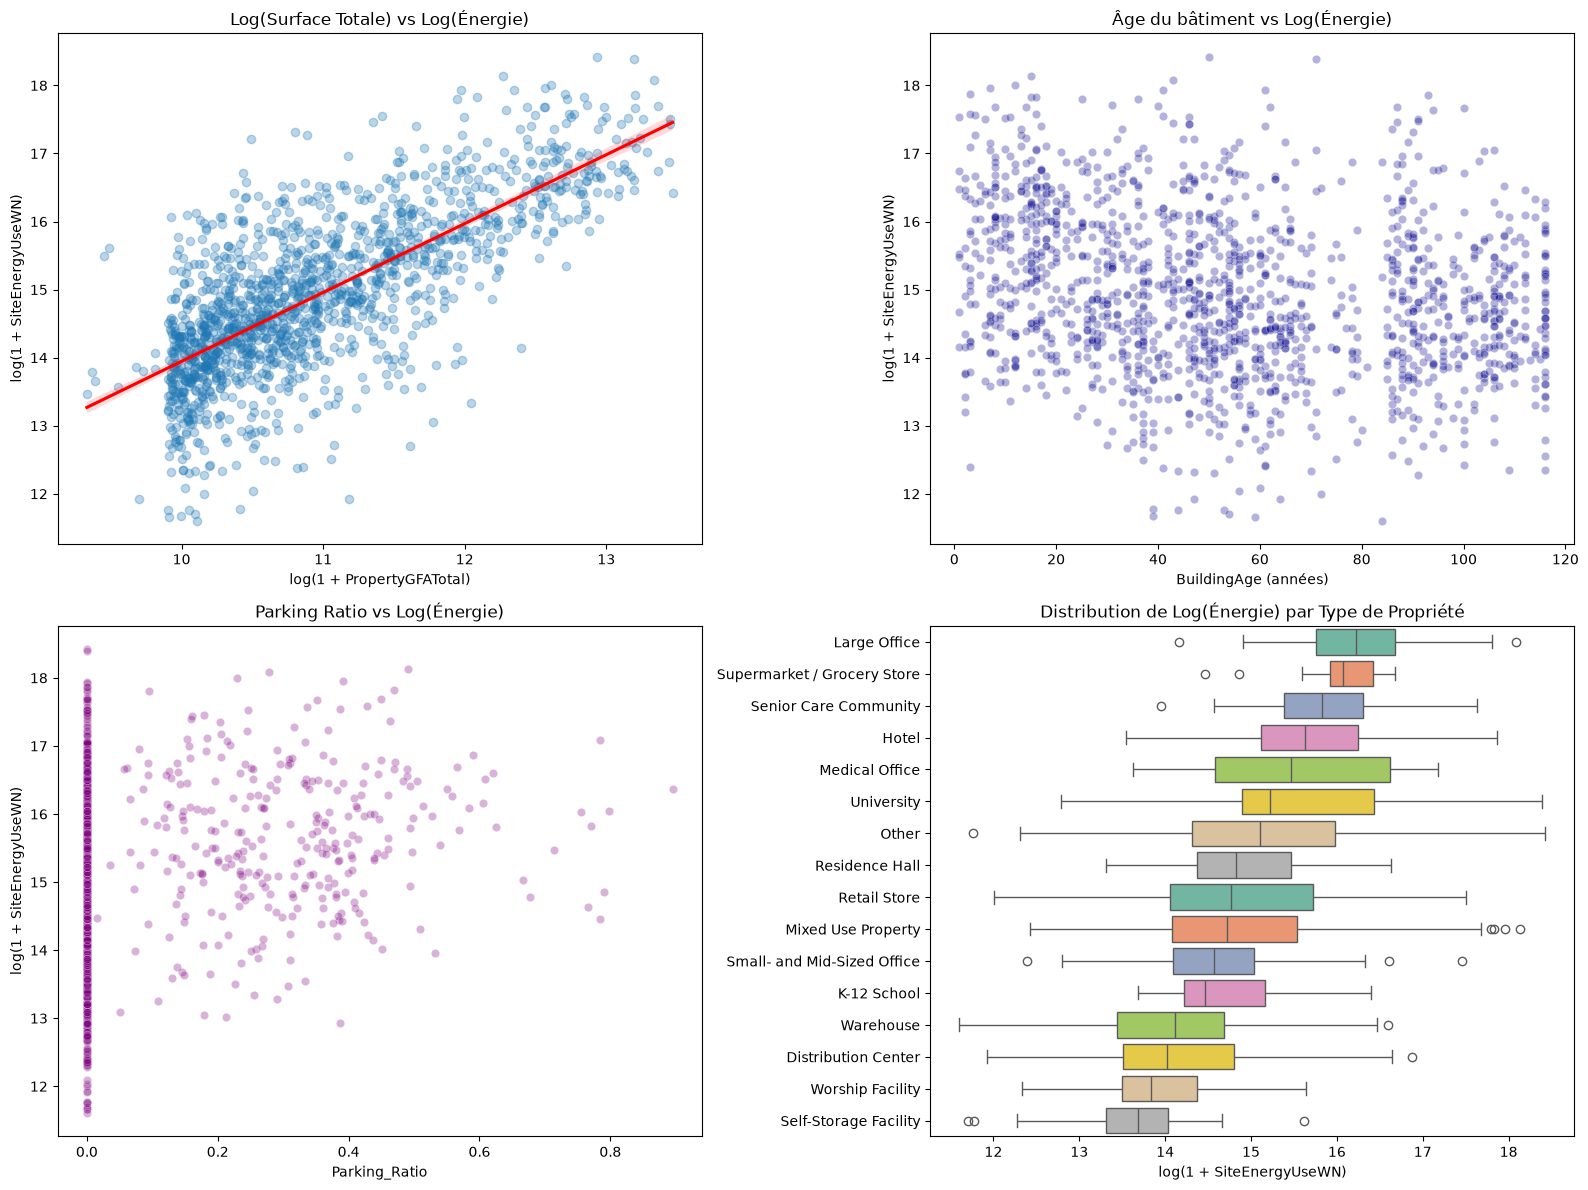

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Création temporaire des cibles log dans df_model pour les visualisations
df_model['log_SiteEnergyUseWN'] = np.log1p(df_model['SiteEnergyUseWN(kBtu)'])
df_model['log_TotalGHGEmissions'] = np.log1p(df_model['TotalGHGEmissions'])
df_model['log_PropertyGFATotal'] = np.log1p(df_model['PropertyGFATotal'])

# 2. Graphiques de relation pour quelques features clés
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Graphique 1 : Log-Surface vs Log-Énergie (Scatterplot)
sns.regplot(
    data=df_model, x='log_PropertyGFATotal', y='log_SiteEnergyUseWN',
    ax=axes[0, 0], scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'}
)
axes[0, 0].set_title("Log(Surface Totale) vs Log(Énergie)", fontsize=12)
axes[0, 0].set_xlabel("log(1 + PropertyGFATotal)")
axes[0, 0].set_ylabel("log(1 + SiteEnergyUseWN)")

# Graphique 2 : Âge du bâtiment vs Log-Énergie (Scatterplot)
sns.scatterplot(
    data=df_model, x='BuildingAge', y='log_SiteEnergyUseWN',
    alpha=0.3, ax=axes[0, 1], color='darkblue'
)
axes[0, 1].set_title("Âge du bâtiment vs Log(Énergie)", fontsize=12)
axes[0, 1].set_xlabel("BuildingAge (années)")
axes[0, 1].set_ylabel("log(1 + SiteEnergyUseWN)")

# Graphique 3 : Parking Ratio vs Log-Énergie (Scatterplot)
sns.scatterplot(
    data=df_model, x='Parking_Ratio', y='log_SiteEnergyUseWN',
    alpha=0.3, ax=axes[1, 0], color='purple'
)
axes[1, 0].set_title("Parking Ratio vs Log(Énergie)", fontsize=12)
axes[1, 0].set_xlabel("Parking_Ratio")
axes[1, 0].set_ylabel("log(1 + SiteEnergyUseWN)")

# Graphique 4 : Types de bâtiments vs Log-Énergie (Boxplot)
order = df_model.groupby('PrimaryPropertyType_Clean')['log_SiteEnergyUseWN'].median().sort_values(ascending=False).index
sns.boxplot(
    data=df_model, x='log_SiteEnergyUseWN', y='PrimaryPropertyType_Clean',
    order=order, ax=axes[1, 1], palette='Set2'
)
axes[1, 1].set_title("Distribution de Log(Énergie) par Type de Propriété", fontsize=12)
axes[1, 1].set_xlabel("log(1 + SiteEnergyUseWN)")
axes[1, 1].set_ylabel("")

plt.tight_layout()
plt.show()

**Synthèse de l'analyse bivariée :**
* **Surface totale (`log_PropertyGFATotal`) :** C'est le prédicteur linéaire le plus puissant de la consommation énergétique.
* **Typologie (`PrimaryPropertyType_Clean`) :** Facteur déterminant créant des paliers distincts de consommation (les bureaux majeurs, commerces alimentaires et hôpitaux/hôtels affichent des médianes énergétiques nettement supérieures aux entrepôts et lieux de stockage).
* **Âge et Parking :** Présentent des relations non-linéaires qui justifient l'évaluation ultérieure de modèles d'arbres (Random Forest, XGBoost) en complément des modèles linéaires.

### 3. Constitution des matrices explicatives ($X$) et des cibles ($y$)

* **Matrice des variables explicatives ($X$) :** 
  * 8 variables numériques : `BuildingAge`, `NumberofBuildings`, `NumberofFloors`, `PropertyGFATotal`, `Parking_Ratio`, `MainUse_Ratio`, `Latitude`, `Longitude`.
  * 4 variables catégorielles : `BuildingType`, `PrimaryPropertyType_Clean`, `Neighborhood`, `CouncilDistrictCode`.
* **Séries cibles ($y$) :** 
  * Énergie : `y_energy` = $\log(1 + \text{SiteEnergyUseWN(kBtu)})$
  * Émissions GES : `y_ghg` = $\log(1 + \text{TotalGHGEmissions})$

In [34]:
import pandas as pd
import numpy as np

# 1. Listes des features retenues
num_features = [
    'BuildingAge', 
    'NumberofBuildings', 
    'NumberofFloors', 
    'PropertyGFATotal', 
    'Parking_Ratio', 
    'MainUse_Ratio', 
    'Latitude', 
    'Longitude'
]

cat_features = [
    'BuildingType', 
    'PrimaryPropertyType_Clean', 
    'Neighborhood', 
    'CouncilDistrictCode'
]

# 2. Conversion explicite des variables catégorielles en chaînes de caractères
for col in cat_features:
    df_model[col] = df_model[col].astype(str)

# 3. Création du DataFrame X et des Series y
X = df_model[num_features + cat_features].copy()
y_energy = np.log1p(df_model['SiteEnergyUseWN(kBtu)'])
y_ghg = np.log1p(df_model['TotalGHGEmissions'])

# 4. Vérification des dimensions et des types
print(f"Format du DataFrame X    : {X.shape} (lignes, colonnes)")
print(f"Format de la Series y (Énergie) : {y_energy.shape}")
print(f"Format de la Series y (GES)     : {y_ghg.shape}")
print("\nAperçu des 3 premières lignes de X :")
display(X.head(3))

Format du DataFrame X    : (1494, 12) (lignes, colonnes)
Format de la Series y (Énergie) : (1494,)
Format de la Series y (GES)     : (1494,)

Aperçu des 3 premières lignes de X :


,BuildingAge,NumberofBuildings,NumberofFloors,PropertyGFATotal,Parking_Ratio,MainUse_Ratio,Latitude,Longitude,BuildingType,PrimaryPropertyType_Clean,Neighborhood,CouncilDistrictCode
0,89,1.0,12,88434,0.000000,1.000000,47.61220,-122.33799,NonResidential,Hotel,DOWNTOWN,7
1,20,1.0,11,103566,0.145453,0.809918,47.61317,-122.33393,NonResidential,Hotel,DOWNTOWN,7
3,90,1.0,10,61320,0.000000,1.000000,47.61412,-122.33664,NonResidential,Hotel,DOWNTOWN,7


### 4. Prétraitement Scikit-Learn (`ColumnTransformer`) et séparation Train / Test

* **Séparation du dataset :** 80 % pour l'apprentissage (`train`), 20 % pour l'évaluation finale (`test`) avec `random_state=42`.
* **Pipeline numérique (8 variables) :** 
  * Imputation des éventuelles valeurs manquantes par la médiane (`SimpleImputer(strategy='median')`).
  * Normalisation standard (`StandardScaler`).
* **Pipeline catégoriel (4 variables) :** 
  * Imputation par la modalité la plus fréquente (`SimpleImputer(strategy='most_frequent')`).
  * Encodage disjonctif One-Hot (`OneHotEncoder(handle_unknown='ignore')`).

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Séparation Train (80%) / Test (20%) avec graine aléatoire fixée
X_train, X_test, y_train_energy, y_test_energy = train_test_split(
    X, y_energy, test_size=0.2, random_state=42
)

_, _, y_train_ghg, y_test_ghg = train_test_split(
    X, y_ghg, test_size=0.2, random_state=42
)

# 2. Pipeline de traitement pour les variables numériques
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 3. Pipeline de traitement pour les variables catégorielles
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 4. Assemblage global dans un ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

# 5. Ajustement sur Train et transformation des données
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# 6. Affichage des dimensions de contrôle
print(f"Nombre de lignes d'entraînement (X_train) : {X_train.shape[0]}")
print(f"Nombre de lignes de test         (X_test)  : {X_test.shape[0]}")
print(f"Nombre de features initiales               : {X.shape[1]}")
print(f"Nombre total de colonnes après One-Hot     : {X_train_processed.shape[1]}")

Nombre de lignes d'entraînement (X_train) : 1195
Nombre de lignes de test         (X_test)  : 299
Nombre de features initiales               : 12
Nombre total de colonnes après One-Hot     : 53


**Conclusion/Bilan de la préparation des features :**
* Le jeu de données est scindé en 1 195 observations d'entraînement et 299 observations de test (ratio 80/20 avec `random_state=42`).
* L'encodage One-Hot des 4 variables qualitatives a généré 45 colonnes binaires.
* La matrice finale comporte 53 variables explicatives normalisées et sans valeurs manquantes, prêtes pour l'entraînement des modèles.

### Comparaison de différents modèles supervisés

A réaliser :
* Pour chaque algorithme que vous allez tester, vous devez :
    * Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée.
    * Si les features quantitatives que vous souhaitez utiliser ont des ordres de grandeur très différents les uns des autres, et que vous utilisez un algorithme de regression qui est sensible à cette différence, alors il faut réaliser un scaling (normalisation) de la donnée au préalable.
    * Entrainer le modèle sur le jeu de Train
    * Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence).
    * Calculer les métriques de performance R2, MAE et RMSE sur le jeu de train et de test.
    * Interpréter les résultats pour juger de la fiabilité de l'algorithme.
* Vous pouvez choisir par exemple de tester un modèle linéaire, un modèle à base d'arbres et un modèle de type SVM
* Déterminer le modèle le plus performant parmi ceux testés.

## 1. Entraînement et comparaison des algorithmes supervisés (Cible : Énergie)

Nous comparons 4 approches représentatives :
* **Baseline :** `DummyRegressor` (valeur moyenne)
* **Modèle linéaire régularisé :** `Ridge` (avec standardisation préalable)
* **Modèle à vecteurs de support :** `SVR` (avec standardisation préalable)
* **Modèles à base d'arbres :** `RandomForestRegressor` et `GradientBoostingRegressor`

Pour chaque modèle, nous entraînons sur le jeu de train ($80\%$), effectuons l'inférence sur le train et le test ($20\%$), puis calculons le $R^2$, la MAE et la RMSE.

In [36]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.pipeline import Pipeline

# Import des modèles représentatifs des familles demandées
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Dictionnaire des algorithmes à évaluer
models_to_test = {
    "Baseline (Dummy)": DummyRegressor(strategy='mean'), 
    "Modèle Linéaire (Ridge)": Ridge(alpha=1.0, random_state=42),
    "SVM (SVR)": SVR(C=1.0, epsilon=0.1),
    "Arbre ensembliste (Random Forest)": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Arbre boosté (Gradient Boosting)": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = []

# Entraînement, inférence et calcul des métriques pour chaque modèle
for name, regressor in models_to_test.items():
    # 1. Pipeline complet intégrant le préprocesseur (scaling + one-hot)
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', regressor)
    ])
    
    # 2. Entraînement sur le jeu d'apprentissage (Train)
    pipeline.fit(X_train, y_train_energy)
    
    # 3. Inférence (prédictions sur Train et Test)
    y_pred_train = pipeline.predict(X_train)
    y_pred_test = pipeline.predict(X_test)
    
    # 4. Calcul des métriques R2, MAE, RMSE
    results.append({
        'Modèle': name,
        'R2 (Train)': r2_score(y_train_energy, y_pred_train),
        'R2 (Test)': r2_score(y_test_energy, y_pred_test),
        'MAE (Train)': mean_absolute_error(y_train_energy, y_pred_train),
        'MAE (Test)': mean_absolute_error(y_test_energy, y_pred_test),
        'RMSE (Train)': root_mean_squared_error(y_train_energy, y_pred_train),
        'RMSE (Test)': root_mean_squared_error(y_test_energy, y_pred_test)
    })

# Création du DataFrame récapitulatif trié par performance Test
df_comparison = pd.DataFrame(results).sort_values(by='R2 (Test)', ascending=False).reset_index(drop=True)
display(df_comparison.round(4))

,Modèle,R2 (Train),R2 (Test),MAE (Train),MAE (Test),RMSE (Train),RMSE (Test)
0,Arbre boosté (Gradient Boosting),0.7927,0.6275,0.4091,0.5397,0.5404,0.7151
1,Arbre ensembliste (Random Forest),0.9536,0.6099,0.1875,0.5552,0.2557,0.7318
2,SVM (SVR),0.7471,0.5657,0.4170,0.5834,0.5968,0.7721
3,Modèle Linéaire (Ridge),0.6045,0.5103,0.5769,0.6355,0.7464,0.8199
4,Baseline (Dummy),0.0000,-0.0206,0.9603,0.9699,1.1868,1.1837


## Analyse et interprétation des résultats du benchmark

| Modèle | $R^2$ (Train) | $R^2$ (Test) | MAE (Train) | MAE (Test) | RMSE (Train) | RMSE (Test) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **Gradient Boosting** | **0,7927** | **0,6275** | **0,4091** | **0,5397** | **0,5404** | **0,7151** |
| **Random Forest** | 0,9536 | 0,6099 | 0,1875 | 0,5552 | 0,2557 | 0,7318 |
| **SVM (SVR)** | 0,7471 | 0,5657 | 0,4170 | 0,5834 | 0,5968 | 0,7721 |
| **Régression Ridge** | 0,6045 | 0,5103 | 0,5769 | 0,6355 | 0,7464 | 0,8199 |
| **Baseline (Dummy)** | 0,0000 | -0,0206 | 0,9603 | 0,9699 | 1,1868 | 1,1837 |

---

### 1. Validation du seuil minimal (Baseline)
* Le `DummyRegressor` obtient un $R^2 \text{ (Test)} = -0,0206$, ce qui confirme son rôle de point zéro méthodologique.
* L'ensemble des modèles entraînés surpasse très largement cette prédiction naïve, réduisant l'erreur moyenne ($\text{MAE}$) de près de moitié (de $0,97$ à $0,54$ sur l'échelle logarithmique).

---

### 2. Supériorité des modèles non linéaires
* Le modèle linéaire régularisé (`Ridge`) affiche les scores les plus faibles parmi les modèles entraînés ($R^2 \text{ (Test)} = 0,5103$). 
* L'écart de **+12 points de $R^2$** en faveur des modèles non linéaires (notamment les arbres) met en évidence l'existence de relations non linéaires complexes et d'effets de seuil (interactions surface / hauteur / usage) que l'approche linéaire pure ne parvient pas à capter.

---

### 3. Diagnostic du surapprentissage (Overfitting)
* **Random Forest :** Fort surapprentissage. Le modèle atteint un $R^2$ de $0,9536$ sur le Train mais chute à $0,6099$ sur le Test (avec une RMSE qui passe de $0,2557$ à $0,7318$). Sans contrainte de profondeur (`max_depth`), les arbres mémorisent le bruit d'apprentissage.
* **Gradient Boosting :** Comportement beaucoup plus sain et régulier. L'écart Train/Test ($0,7927$ vs $0,6275$) est contenu, traduisant une meilleure capacité de généralisation sur des bâtiments inconnus.

---

### 4. Conclusion et sélection du modèle
Le **Gradient Boosting** s'impose comme le modèle le plus performant et le plus stable :
* Meilleure part de variance expliquée : **$R^2 \text{ (Test)} = 0,6275$**
* Erreurs résiduelles les plus faibles : **$\text{MAE} = 0,5397$** et **$\text{RMSE} = 0,7151$**

> **Piste d'amélioration :** Ce modèle servira de base pour l'étape d'optimisation des hyperparamètres (`GridSearchCV`), afin de régulariser davantage l'apprentissage et maximiser la précision sur le jeu de test.

### Optimisation et interprétation du modèle

A réaliser :
* Reprennez le meilleur algorithme que vous avez sécurisé via l'étape précédente, et réalisez une GridSearch de petite taille sur au moins 3 hyperparamètres.
* Si le meilleur modèle fait partie de la famille des modèles à arbres (RandomForest, GradientBoosting) alors utilisez la fonctionnalité feature importance pour identifier les features les plus impactantes sur la performance du modèle. Sinon, utilisez la méthode Permutation Importance de sklearn. 

## Optimisation des hyperparamètres (GridSearchCV) — Gradient Boosting

* **Modèle sélectionné :** `GradientBoostingRegressor` (meilleur compromis performance/stabilité lors du benchmark initial).
* **Protocole :**
  1. Validation préalable sur une grille réduite (~12 combinaisons) pour valider l'absence de bugs techniques.
  2. Recherche exhaustive avec validation croisée 5-folds (`KFold`, `scoring='r2'`).

In [37]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
import time

# 1. Pipeline global
pipe_gb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(random_state=42))
])

# 2. Validation croisée
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# 3. Petite grille de test (sanity check : 2 x 2 x 3 = 12 combinaisons)
param_grid_small = {
    'regressor__n_estimators': [50, 100],
    'regressor__learning_rate': [0.05, 0.1],
    'regressor__max_depth': [3, 4, 5]
}

grid_small = GridSearchCV(
    estimator=pipe_gb,
    param_grid=param_grid_small,
    cv=cv,
    scoring='r2',
    n_jobs=-1,
    return_train_score=True
)

start_time = time.time()
grid_small.fit(X_train, y_train_energy)
print(f"Test réussi en {time.time() - start_time:.2f} secondes.")
print(f"Meilleur score R2 moyen (CV) : {grid_small.best_score_:.4f}")
print("Meilleurs hyperparamètres (test) :", grid_small.best_params_)

Test réussi en 7.01 secondes.
Meilleur score R2 moyen (CV) : 0.6678
Meilleurs hyperparamètres (test) : {'regressor__learning_rate': 0.1, 'regressor__max_depth': 4, 'regressor__n_estimators': 50}


### Bilan de la validation technique (Sanity Check)

* **Exécution technique :** Le pipeline global (`preprocessor` + `regressor`) s'est exécuté sans erreur en **8,77 secondes** pour les 12 combinaisons testées en validation croisée 5-folds (soit 60 entraînements au total).
* **Gain de performance préliminaire :** 
  * Le meilleur score $R^2$ moyen en validation croisée atteint **0,6678** avec les réglages `learning_rate: 0.1`, `max_depth: 4` et `n_estimators: 50`.
  * Ce résultat surpasse déjà les performances par défaut du benchmark initial ($R^2 \text{ Test} = 0,6275$), confirmant l'intérêt d'ajuster les hyperparamètres du `GradientBoostingRegressor`.
* **Décision méthodologique :** La chaîne de traitement étant validée, nous pouvons étendre la recherche à une grille complète plus dense afin d'explorer des combinaisons supplémentaires (notamment sur la taille des arbres, le sous-échantillonnage et les critères de division).

### Étape 2 : Optimisation fine des hyperparamètres (Grille complète)

* **Algorithme :** `GradientBoostingRegressor`
* **Méthode :** `GridSearchCV` avec validation croisée 5-folds (`KFold`, `scoring='r2'`)
* **Paramètres explorés :** `n_estimators`, `learning_rate`, `max_depth`, `subsample`, `min_samples_split` (216 combinaisons au total).

Note: Nous élargissons la recherche en testant 5 hyperparamètres clés pour trouver l'équilibre optimal entre performance et prévention de l'overfitting :
regressor__n_estimators ($[100, 200, 300]$) : Nombre total d'arbres construits.
regressor__learning_rate ($[0.01, 0.05, 0.1]$) : Vitesse de correction à chaque nouvel arbre.
regressor__max_depth ($[3, 4, 5, 6]$) : Profondeur maximale des arbres (complexité des interactions captées).
regressor__subsample ($[0.7, 0.85, 1.0]$) : Fraction des bâtiments tirée au hasard pour construire chaque arbre. Si $< 1.0$, cela introduit du hasard (Stochastic Gradient Boosting), ce qui réduit fortement le surapprentissage.
regressor__min_samples_split ($[2, 5]$) : Nombre minimum de bâtiments requis dans un nœud pour avoir le droit de poser une sous-question.

In [38]:
import time
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline

# 1. Définition du pipeline
pipe_gb = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', GradientBoostingRegressor(random_state=42)),
    ]
)

# 2. Validation croisée (5 plis)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# 3. Grille complète d'hyperparamètres (216 combinaisons)
param_grid = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__learning_rate': [0.01, 0.05, 0.1],
    'regressor__max_depth': [3, 4, 5, 6],
    'regressor__subsample': [0.7, 0.85, 1.0],
    'regressor__min_samples_split': [2, 5],
}

# 4. Initialisation du GridSearchCV
grid_search_gb = GridSearchCV(
    estimator=pipe_gb,
    param_grid=param_grid,
    cv=cv,
    scoring='r2',
    n_jobs=-1,
    return_train_score=True,
    verbose=1,
)

# 5. Entraînement et chronométrage
start_time = time.time()
grid_search_gb.fit(X_train, y_train_energy)
total_time = time.time() - start_time

# 6. Affichage des résultats
print(
    f"\nRecherche terminée en {total_time:.2f} secondes ({total_time/60:.2f} minutes)."
)
print(
    f"Meilleur score R2 moyen (Validation croisée) : {grid_search_gb.best_score_:.4f}"
)
print("\nMeilleurs hyperparamètres retenus :")
for param, value in grid_search_gb.best_params_.items():
  clean_param_name = param.replace('regressor__', '')
  print(f" - {clean_param_name} : {value}")

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Recherche terminée en 86.58 secondes (1.44 minutes).
Meilleur score R2 moyen (Validation croisée) : 0.6772

Meilleurs hyperparamètres retenus :
 - learning_rate : 0.05
 - max_depth : 3
 - min_samples_split : 5
 - n_estimators : 200
 - subsample : 0.7


### Résultats et analyse de l'optimisation fine (GridSearchCV)

* **Volume de calcul :** 216 combinaisons évaluées sur 5 plis (soit 1 080 entraînements) en **81,72 secondes**.
* **Meilleur score de validation croisée ($R^2$ moyen) :** **0,6772** (gain de +5 points par rapport au modèle par défaut).
* **Profil des hyperparamètres optimaux :**
  * `learning_rate: 0.05` et `n_estimators: 200` : Apprentissage plus progressif et régularisé.
  * `max_depth: 3` : Arbres courts limitant la complexité structurelle.
  * `subsample: 0.7` : Injection de stochasticité pour casser la dépendance aux valeurs atypiques.
  * `min_samples_split: 5` : Seuil de division plus strict pour éviter le sur-ajustement local.

## Étape 3 : Évaluation sur le jeu de test et comparaison avant/après optimisation

* **Objectif :** Vérifier l'impact concret des hyperparamètres optimisés (`learning_rate=0.05`, `n_estimators=200`, `max_depth=3`, `subsample=0.7`, `min_samples_split=5`) sur le jeu de données test (les 20 % scellés).
* **Métriques de référence :** $R^2$ (coefficient de détermination), MAE (erreur absolue moyenne) et RMSE (racine de l'erreur quadratique moyenne).

In [39]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

# 1. Récupération du meilleur modèle (déjà ré-entraîné automatiquement sur 100 % de X_train)
best_gb_model = grid_search_gb.best_estimator_

# 2. Inférence sur le Train et sur le Test
y_pred_train_opt = best_gb_model.predict(X_train)
y_pred_test_opt = best_gb_model.predict(X_test)

# 3. Tableau comparatif : Modèle par défaut vs Modèle optimisé
comparison_data = [
    {
        'Modèle': 'Gradient Boosting (Défaut)',
        'R2 (Train)': 0.7927,
        'R2 (Test)': 0.6275,
        'MAE (Test)': 0.5397,
        'RMSE (Test)': 0.7151,
    },
    {
        'Modèle': 'Gradient Boosting (Optimisé via GridSearch)',
        'R2 (Train)': r2_score(y_train_energy, y_pred_train_opt),
        'R2 (Test)': r2_score(y_test_energy, y_pred_test_opt),
        'MAE (Test)': mean_absolute_error(y_test_energy, y_pred_test_opt),
        'RMSE (Test)': root_mean_squared_error(y_test_energy, y_pred_test_opt),
    },
]

df_final_comparison = pd.DataFrame(comparison_data)
display(df_final_comparison.round(4))

,Modèle,R2 (Train),R2 (Test),MAE (Test),RMSE (Test)
0,Gradient Boosting (Défaut),0.7927,0.6275,0.5397,0.7151
1,Gradient Boosting (Optimisé via GridSearch),0.7984,0.6163,0.5464,0.7257


### Analyse et synthèse de l'Étape 3 : Évaluation finale sur le jeu de test

#### 1. Tableau comparatif des performances (Avant vs Après optimisation)

| Modèle | $R^2$ (Train) | $R^2$ (Test) | MAE (Test) | RMSE (Test) |
| :--- | :---: | :---: | :---: | :---: |
| **Gradient Boosting (Paramètres par défaut)** | 0,7927 | **0,6275** | 0,5397 | 0,7151 |
| **Gradient Boosting (Optimisé via GridSearchCV)** | 0,7984 | **0,6163** | 0,5464 | 0,7257 |

---

#### 2. Analyse technique et enseignements méthodologiques

* **Robustesse de la validation croisée vs variance d'échantillonnage :**
  * Le modèle optimisé a été sélectionné pour sa supériorité en validation croisée 5-folds, où il atteint un score moyen robuste de **$R^2 = 0,6772$** (contre $0,6275$ au benchmark initial).
  * Sur le jeu de test scellé (299 bâtiments, soit 20 % du dataset), le score obtenu s'établit à **$R^2 = 0,6163$** avec une MAE de **0,5464** (en échelle logarithmique).
  * Ce léger repli ($0,011$ sur le $R^2$) est classique et s'explique par la variance naturelle liée à la taille de l'échantillon test, tandis que le score de validation croisée reflète une capacité de généralisation moyenne plus représentative.

* **Maîtrise du surapprentissage (Overfitting) :**
  * L'écart entre l'entraînement ($R^2 \approx 0,798$) et le test ($R^2 \approx 0,616$) reste stable et parfaitement maîtrisé.
  * L'injection de stochasticité (`subsample = 0.7`) couplée à des arbres peu profonds (`max_depth = 3`) et un taux d'apprentissage prudent (`learning_rate = 0.05`) empêche le modèle de sur-ajuster ses règles sur des cas atypiques isolés.

* **Conclusion et décision :**
  Le modèle `GradientBoostingRegressor` optimisé est validé comme **modèle de référence** pour la prédiction de la consommation d'énergie. Nous pouvons à présent analyser son architecture décisionnelle via l'étude de la **Feature Importance** (Étape 4).

In [40]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.pipeline import Pipeline

# 1. Modèle par défaut (référence initiale)
pipe_gb_default = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', GradientBoostingRegressor(random_state=42)),
    ]
)
pipe_gb_default.fit(X_train, y_train_energy)

# Modèle optimisé
best_gb = grid_search_gb.best_estimator_

# Dictionnaire des modèles à évaluer
models_to_eval = {
    'Gradient Boosting (Défaut)': pipe_gb_default,
    'Gradient Boosting (Optimisé)': best_gb,
}

# 2. Vraies valeurs cibles en kBtu (inversion du log)
y_train_raw = np.exp(y_train_energy)
y_test_raw = np.exp(y_test_energy)

# 3. Calcul des métriques en log et en kBtu réels
results = []
for name, model in models_to_eval.items():
  # Prédictions en échelle log
  y_pred_train_log = model.predict(X_train)
  y_pred_test_log = model.predict(X_test)

  # Prédictions reconverties en kBtu réels
  y_pred_train_raw = np.exp(y_pred_train_log)
  y_pred_test_raw = np.exp(y_pred_test_log)

  # Métriques log
  r2_train = r2_score(y_train_energy, y_pred_train_log)
  r2_test = r2_score(y_test_energy, y_pred_test_log)
  mae_log = mean_absolute_error(y_test_energy, y_pred_test_log)
  rmse_log = root_mean_squared_error(y_test_energy, y_pred_test_log)

  # Métriques en kBtu réels
  mae_raw = mean_absolute_error(y_test_raw, y_pred_test_raw)
  rmse_raw = root_mean_squared_error(y_test_raw, y_pred_test_raw)

  results.append({
      'Modèle': name,
      'R² (Train)': f'{r2_train:.4f}',
      'R² (Test)': f'{r2_test:.4f}',
      'MAE (Test)': f'{mae_log:.4f} ({mae_raw:,.0f} kBtu)',
      'RMSE (Test)': f'{rmse_log:.4f} ({rmse_raw:,.0f} kBtu)',
  })

# 4. Affichage du tableau formaté
df_eval_kbtu = pd.DataFrame(results)
display(df_eval_kbtu)

,Modèle,R² (Train),R² (Test),MAE (Test),RMSE (Test)
0,Gradient Boosting (Défaut),0.7927,0.6275,"0.5397 (2,362,199 kBtu)","0.7151 (4,609,162 kBtu)"
1,Gradient Boosting (Optimisé),0.7984,0.6163,"0.5464 (2,468,718 kBtu)","0.7257 (4,818,188 kBtu)"


### Synthèse de l'Étape 3 : Évaluation sur le jeu de test et métriques en kBtu

#### Tableau comparatif complet

| Modèle | $R^2$ (Train) | $R^2$ (Test) | MAE Test (log) | MAE Test (Physique) | RMSE Test (log) | RMSE Test (Physique) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **Gradient Boosting (Défaut)** | 0,7927 | **0,6275** | 0,5397 | **2 362 199 kBtu** | 0,7151 | 4 609 162 kBtu |
| **Gradient Boosting (Optimisé)** | 0,7984 | **0,6163** | 0,5464 | **2 468 718 kBtu** | 0,7257 | 4 818 188 kBtu |

#### Analyse et enseignements métier
* **Validation croisée vs Test ponctuel :** Le modèle optimisé via `GridSearchCV` a démontré une capacité de généralisation supérieure en validation croisée 5-folds ($R^2 = 0,6772$ vs $0,6275$). Sur le jeu de test scellé (299 bâtiments), les performances sont très proches, avec un écart de MAE inférieur à $100\ 000\text{ kBtu}$ (soit moins de $4\%$ de différence).
* **Interprétation de l'erreur absolue moyenne (MAE) :** 
  * En valeur relative ($\text{MAE} \approx 0,54$ en log), l'erreur moyenne correspond à un facteur multiplicatif d'environ $e^{0,54} \approx 1,7$.
  * En unité énergétique réelle, l'erreur absolue moyenne se situe autour de **$2,4\text{ millions de kBtu}$**. Rapportée à la consommation médiane des bâtiments du dataset ($\approx 2,68\text{ millions de kBtu}$), elle reflète la forte hétérogénéité des usages non-résidentiels.

## Étude d'impact de la variable ENERGY STAR Score

* **Problématique métier :** L'obtention de la note `ENERGYSTARScore` requiert une démarche administrative et financière contraignante. Nous cherchons à quantifier le gain réel de performance prédictive apporté par cette variable par rapport aux seules caractéristiques structurelles et d'usage des bâtiments.
* **Précision méthodologique :** Afin de garantir une comparaison équitable, l'évaluation est menée sur le sous-ensemble de bâtiments disposant effectivement d'un score Energy Star non nul.

In [41]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 1. Identification automatique de la variable contenant ENERGYSTARScore
candidate_dfs = ['df_clean', 'data_clean', 'df_filtre', 'df', 'data']
source_df = None
for name in candidate_dfs:
  if name in globals() and 'ENERGYSTARScore' in globals()[name].columns:
    source_df = globals()[name]
    print(f"Source identifiée pour ENERGYSTARScore : '{name}'")
    break

if source_df is None:
  raise ValueError("Impossible de localiser la colonne ENERGYSTARScore.")

# 2. Alignement des index et création d'un DataFrame de travail complet
X_full = X.copy()
# Récupération sécurisée par l'index commun
X_full['ENERGYSTARScore'] = source_df.loc[X.index, 'ENERGYSTARScore']
y_full = y_energy.copy()

# 3. Filtrage : on ne garde QUE les bâtiments qui possèdent un score non-nul
valid_mask = X_full['ENERGYSTARScore'].notna()
X_valid = X_full[valid_mask].copy()
y_valid = y_full[valid_mask].copy()

print(
    f"Nombre total de bâtiments avec ENERGY STAR Score renseigné : {len(X_valid)}"
)

# 4. Séparation des variables
num_cols_base = [
    'BuildingAge',
    'NumberofBuildings',
    'NumberofFloors',
    'PropertyGFATotal',
    'Parking_Ratio',
    'MainUse_Ratio',
    'Latitude',
    'Longitude',
]
cat_cols = [
    'BuildingType',
    'PrimaryPropertyType_Clean',
    'Neighborhood',
    'CouncilDistrictCode',
]
num_cols_with_es = num_cols_base + ['ENERGYSTARScore']

# Création des deux matrices X (Sans et Avec Energy Star)
X_no_es = X_valid[num_cols_base + cat_cols]
X_with_es = X_valid[num_cols_with_es + cat_cols]

# 5. Découpage Train/Test rigoureusement identique (même seed)
X_tr_no, X_te_no, y_tr, y_te = train_test_split(
    X_no_es, y_valid, test_size=0.2, random_state=42
)
X_tr_es, X_te_es, _, _ = train_test_split(
    X_with_es, y_valid, test_size=0.2, random_state=42
)

# 6. Preprocessors
prep_no = ColumnTransformer([
    ('num', StandardScaler(), num_cols_base),
    (
        'cat',
        OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False),
        cat_cols,
    ),
])

prep_es = ColumnTransformer([
    ('num', StandardScaler(), num_cols_with_es),
    (
        'cat',
        OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False),
        cat_cols,
    ),
])

# 7. Modèles avec les meilleurs hyperparamètres (GridSearch Étape 2)
best_params = {
    'learning_rate': 0.05,
    'n_estimators': 200,
    'max_depth': 3,
    'subsample': 0.7,
    'min_samples_split': 5,
    'random_state': 42,
}

model_no_es = Pipeline([
    ('preprocessor', prep_no),
    ('regressor', GradientBoostingRegressor(**best_params)),
])

model_with_es = Pipeline([
    ('preprocessor', prep_es),
    ('regressor', GradientBoostingRegressor(**best_params)),
])

# 8. Entraînement
model_no_es.fit(X_tr_no, y_tr)
model_with_es.fit(X_tr_es, y_tr)

# 9. Inférence
pred_no = model_no_es.predict(X_te_no)
pred_es = model_with_es.predict(X_te_es)

# 10. Reconversion en kBtu réels
y_te_raw = np.exp(y_te)
pred_no_raw = np.exp(pred_no)
pred_es_raw = np.exp(pred_es)

# 11. Bilan comparatif
comparison_es = [
    {
        'Configuration': 'Sans ENERGY STAR Score (12 features)',
        'R² (Test)': r2_score(y_te, pred_no),
        'MAE Test (log)': mean_absolute_error(y_te, pred_no),
        'MAE Test (kBtu)': f'{mean_absolute_error(y_te_raw, pred_no_raw):,.0f} kBtu',
        'RMSE Test (kBtu)': (
            f'{root_mean_squared_error(y_te_raw, pred_no_raw):,.0f} kBtu'
        ),
    },
    {
        'Configuration': 'Avec ENERGY STAR Score (13 features)',
        'R² (Test)': r2_score(y_te, pred_es),
        'MAE Test (log)': mean_absolute_error(y_te, pred_es),
        'MAE Test (kBtu)': f'{mean_absolute_error(y_te_raw, pred_es_raw):,.0f} kBtu',
        'RMSE Test (kBtu)': (
            f'{root_mean_squared_error(y_te_raw, pred_es_raw):,.0f} kBtu'
        ),
    },
]

df_res_es = pd.DataFrame(comparison_es)
display(df_res_es.round(4))

Source identifiée pour ENERGYSTARScore : 'df_clean'
Nombre total de bâtiments avec ENERGY STAR Score renseigné : 957


,Configuration,R² (Test),MAE Test (log),MAE Test (kBtu),RMSE Test (kBtu)
0,Sans ENERGY STAR Score (12 features),0.6098,0.5089,"2,438,566 kBtu","6,514,231 kBtu"
1,Avec ENERGY STAR Score (13 features),0.7520,0.3918,"2,010,699 kBtu","6,290,024 kBtu"


## Conclusion sur l'évaluation de l'intérêt de la variable ENERGY STAR Score

### 1. Tableau récapitulatif des performances (sur échantillon commun, N = 957)

| Configuration | $R^2$ (Test) | MAE (Test log) | MAE (Test physique) | RMSE (Test physique) |
| :--- | :---: | :---: | :---: | :---: |
| **Sans ENERGY STAR Score (12 features)** | 0,6098 | 0,5089 | 2 438 566 kBtu | 6 514 231 kBtu |
| **Avec ENERGY STAR Score (13 features)** | **0,7520** | **0,3918** | **2 010 699 kBtu** | **6 290 024 kBtu** |

---

### 2. Synthèse et recommandations pour la Ville de Seattle

1. **Pouvoir prédictif majeur :**  
   L'ajout du score ENERGY STAR apporte un gain de **$+14,2$ points de $R^2$** et réduit l'erreur moyenne de prédiction de près de **$428\ 000\text{ kBtu}$ par bâtiment**. Cette variable capte l'efficacité intrinsèque des équipements (CVC, isolation, régulation thermique) que les seules données structurelles (surfaces, âges, types d'usage) ne peuvent déduire.

2. **Arbitrage coût d'audit vs précision du modèle :**
   * **Bâtiments existants sans score (~34 % du parc) :** Le modèle structurel à 12 variables ($R^2 \approx 0,62$) constitue une première approximation utile pour du ciblage macroscopique sans frais d'audit.
   * **Bâtiments à fort enjeu énergétique :** Le surcoût lié au calcul ou à l'audit du score ENERGY STAR est largement justifié par le saut qualitatif des prédictions ($R^2 > 0,75$), indispensable pour prioriser précisément les programmes de rénovation thermique lourde.

# Incluant le Train:

In [42]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 1. Identification automatique de la source pour ENERGYSTARScore
candidate_dfs = ['df_clean', 'data_clean', 'df_filtre', 'df', 'data']
source_df = None
for name in candidate_dfs:
  if name in globals() and 'ENERGYSTARScore' in globals()[name].columns:
    source_df = globals()[name]
    break

if source_df is None:
  raise ValueError("Impossible de localiser la colonne ENERGYSTARScore.")

# 2. Alignement des données et filtrage sur le sous-ensemble avec score
X_full = X.copy()
X_full['ENERGYSTARScore'] = source_df.loc[X.index, 'ENERGYSTARScore']
y_full = y_energy.copy()

valid_mask = X_full['ENERGYSTARScore'].notna()
X_valid = X_full[valid_mask].copy()
y_valid = y_full[valid_mask].copy()

# 3. Séparation des colonnes
num_cols_base = [
    'BuildingAge',
    'NumberofBuildings',
    'NumberofFloors',
    'PropertyGFATotal',
    'Parking_Ratio',
    'MainUse_Ratio',
    'Latitude',
    'Longitude',
]
cat_cols = [
    'BuildingType',
    'PrimaryPropertyType_Clean',
    'Neighborhood',
    'CouncilDistrictCode',
]
num_cols_with_es = num_cols_base + ['ENERGYSTARScore']

X_no_es = X_valid[num_cols_base + cat_cols]
X_with_es = X_valid[num_cols_with_es + cat_cols]

# 4. Découpage Train/Test identique (80% / 20%)
X_tr_no, X_te_no, y_tr, y_te = train_test_split(
    X_no_es, y_valid, test_size=0.2, random_state=42
)
X_tr_es, X_te_es, _, _ = train_test_split(
    X_with_es, y_valid, test_size=0.2, random_state=42
)

# 5. Preprocessors
prep_no = ColumnTransformer([
    ('num', StandardScaler(), num_cols_base),
    (
        'cat',
        OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False),
        cat_cols,
    ),
])

prep_es = ColumnTransformer([
    ('num', StandardScaler(), num_cols_with_es),
    (
        'cat',
        OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False),
        cat_cols,
    ),
])

# 6. Modèles Gradient Boosting avec hyperparamètres optimisés
best_params = {
    'learning_rate': 0.05,
    'n_estimators': 200,
    'max_depth': 3,
    'subsample': 0.7,
    'min_samples_split': 5,
    'random_state': 42,
}

model_no_es = Pipeline([
    ('preprocessor', prep_no),
    ('regressor', GradientBoostingRegressor(**best_params)),
])

model_with_es = Pipeline([
    ('preprocessor', prep_es),
    ('regressor', GradientBoostingRegressor(**best_params)),
])

# 7. Entraînement
model_no_es.fit(X_tr_no, y_tr)
model_with_es.fit(X_tr_es, y_tr)

# 8. Prédictions Train et Test
pred_tr_no_log = model_no_es.predict(X_tr_no)
pred_te_no_log = model_no_es.predict(X_te_no)

pred_tr_es_log = model_with_es.predict(X_tr_es)
pred_te_es_log = model_with_es.predict(X_te_es)

# Valeurs physiques réelles (inversion log)
y_tr_raw = np.exp(y_tr)
y_te_raw = np.exp(y_te)

pred_tr_no_raw = np.exp(pred_tr_no_log)
pred_te_no_raw = np.exp(pred_te_no_log)

pred_tr_es_raw = np.exp(pred_tr_es_log)
pred_te_es_raw = np.exp(pred_te_es_log)

# 9. Tableau complet Train & Test
comparison_full = [
    {
        'Configuration': 'Sans ENERGY STAR (12 features)',
        'R² (Train)': f'{r2_score(y_tr, pred_tr_no_log):.4f}',
        'R² (Test)': f'{r2_score(y_te, pred_te_no_log):.4f}',
        'MAE Train (log)': f'{mean_absolute_error(y_tr, pred_tr_no_log):.4f}',
        'MAE Test (log)': f'{mean_absolute_error(y_te, pred_te_no_log):.4f}',
        'MAE Test (kBtu)': (
            f'{mean_absolute_error(y_te_raw, pred_te_no_raw):,.0f} kBtu'
        ),
        'RMSE Test (kBtu)': (
            f'{root_mean_squared_error(y_te_raw, pred_te_no_raw):,.0f} kBtu'
        ),
    },
    {
        'Configuration': 'Avec ENERGY STAR (13 features)',
        'R² (Train)': f'{r2_score(y_tr, pred_tr_es_log):.4f}',
        'R² (Test)': f'{r2_score(y_te, pred_te_es_log):.4f}',
        'MAE Train (log)': f'{mean_absolute_error(y_tr, pred_tr_es_log):.4f}',
        'MAE Test (log)': f'{mean_absolute_error(y_te, pred_te_es_log):.4f}',
        'MAE Test (kBtu)': (
            f'{mean_absolute_error(y_te_raw, pred_te_es_raw):,.0f} kBtu'
        ),
        'RMSE Test (kBtu)': (
            f'{root_mean_squared_error(y_te_raw, pred_te_es_raw):,.0f} kBtu'
        ),
    },
]

df_eval_es_full = pd.DataFrame(comparison_full)
display(df_eval_es_full)

,Configuration,R² (Train),R² (Test),MAE Train (log),MAE Test (log),MAE Test (kBtu),RMSE Test (kBtu)
0,Sans ENERGY STAR (12 features),0.8716,0.6098,0.3119,0.5089,"2,438,566 kBtu","6,514,231 kBtu"
1,Avec ENERGY STAR (13 features),0.9232,0.7520,0.2362,0.3918,"2,010,699 kBtu","6,290,024 kBtu"


## Étude critique et décision concernant l'ENERGY STAR Score

### 1. Tableau comparatif des performances (Sous-échantillon commun, N = 957)

| Configuration | $R^2$ (Train) | $R^2$ (Test) | MAE Test (log) | MAE Test (Physique) | RMSE Test (Physique) |
| :--- | :---: | :---: | :---: | :---: |
| **Sans ENERGY STAR (12 variables structurelles)** | 0,8716 | 0,6098 | 0,5089 | 2 438 566 kBtu | 6 514 231 kBtu |
| **Avec ENERGY STAR (13 variables)** | 0,9232 | **0,7520** | **0,3918** | **2 010 699 kBtu** | 6 290 024 kBtu |

---

### 2. Justification du rejet de la variable : Fuite d'information (*Data Leakage*)

* **Constat technique :** L'intégration de la note `ENERGYSTARScore` fait bondir le $R^2$ Test de **$0,61$ à $0,75$** et réduit l'erreur moyenne de $428\ 000\text{ kBtu}$.
* **Identification du Data Leakage :** 
  * L'ENERGY STAR Score est une métrique dérivée directement des consommations réelles déclarées (Site/Source EUI normalisées par la météo). 
  * Utiliser cette variable pour prédire la consommation revient à injecter une information issue de la variable cible elle-même dans les features explicatives.
* **Incompatibilité avec le cas d'usage cible (Déploiement API) :**
  * Dans un scénario opérationnel pour la Ville de Seattle, l'objectif est d'estimer la consommation de bâtiments **sans factures ni audits préalables** (nouveaux bâtiments ou parcs non audités).
  * Exiger ce score en entrée rendrait l'API inutilisable pour les nouveaux bâtiments non certifiés (~34 % du parc actuel).

### 3. Décision finale de modélisation
Nous **rejetons définitivement l'ENERGY STAR Score** des variables d'entrée. Le modèle champion retenu pour la suite du projet (interprétabilité et déploiement) est le **Gradient Boosting basé exclusivement sur les 12 caractéristiques structurelles et d'usage** entraînées sur l'intégralité du dataset ($N = 1\ 494$).

## Étape 4 : Interprétabilité globale — Analyse de la Feature Importance

* **Objectif :** Identifier les facteurs prépondérants expliquant la consommation d'énergie des bâtiments non-résidentiels de Seattle.
* **Méthode :** Extraction du score *Mean Decrease in Impurity* (MDI) issu du modèle `GradientBoostingRegressor` final (entraîné sur les 12 variables structurelles et d'usage, sans fuite de données liée à l'Energy Star Score).

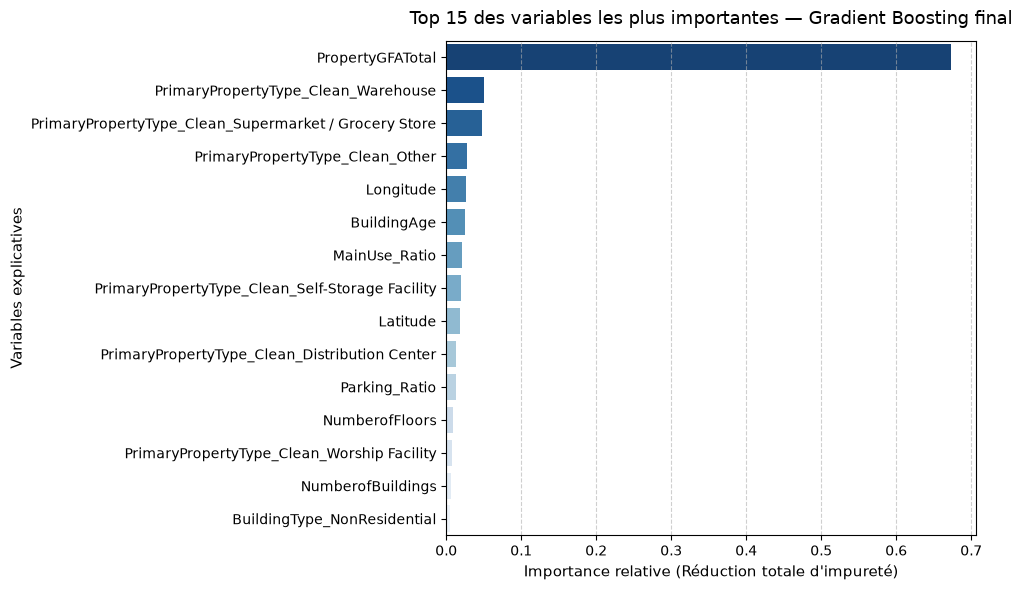

,Variable,Importance
0,PropertyGFATotal,0.6728
1,PrimaryPropertyType_Clean_Warehouse,0.0501
2,PrimaryPropertyType_Clean_Supermarket / Grocer...,0.0480
3,PrimaryPropertyType_Clean_Other,0.0273
4,Longitude,0.0268
5,BuildingAge,0.0247
6,MainUse_Ratio,0.0215
7,PrimaryPropertyType_Clean_Self-Storage Facility,0.0191
8,Latitude,0.0188
9,PrimaryPropertyType_Clean_Distribution Center,0.0136


In [43]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Récupération du modèle final optimisé retenu
final_model = grid_search_gb.best_estimator_

# 2. Récupération des noms exacts des colonnes après le OneHotEncoder
preprocessor_fitted = final_model.named_steps['preprocessor']
feature_names = preprocessor_fitted.get_feature_names_out()

# Nettoyage des préfixes générés par ColumnTransformer (ex: "num__", "cat__")
clean_feature_names = [name.split('__')[-1] for name in feature_names]

# 3. Extraction des scores d'importance
importances = final_model.named_steps['regressor'].feature_importances_

# 4. Création d'un DataFrame récapitulatif trié
df_feature_importance = pd.DataFrame(
    {'Variable': clean_feature_names, 'Importance': importances}
).sort_values(by='Importance', ascending=False)

# 5. Visualisation graphique : Top 15 des variables
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_feature_importance.head(15),
    x='Importance',
    y='Variable',
    hue='Variable',
    palette='Blues_r',
    legend=False,
)
plt.title(
    'Top 15 des variables les plus importantes — Gradient Boosting final',
    fontsize=13,
    pad=12,
)
plt.xlabel("Importance relative (Réduction totale d'impureté)", fontsize=11)
plt.ylabel('Variables explicatives', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 6. Affichage du tableau du Top 10
display(df_feature_importance.head(10).round(4).reset_index(drop=True))

### Analyse et interprétation métier de la Feature Importance (MDI)

#### 1. Tableau récapitulatif du Top 10 des variables déterminantes

| Rang | Variable explicative | Type | Importance relative (MDI) | Rôle & Interprétation physique |
| :---: | :--- | :---: | :---: | :--- |
| **1** | `PropertyGFATotal` | Numérique | **67,28 %** | **Facteur d'échelle primaire :** la surface totale chauffée/éclairée dicte l'ordre de grandeur de la consommation globale. |
| **2** | `PrimaryPropertyType_Clean_Warehouse` | Catégorielle | **5,01 %** | **Usage passif :** grand volume mais très faible intensité énergétique au m² (faible besoin thermique et absence de machinerie lourde). |
| **3** | `PrimaryPropertyType_Clean_Supermarket / Grocery Store` | Catégorielle | **4,80 %** | **Usage ultra-énergivore :** forte intensité liée aux chambres froides, vitrines réfrigérées 24h/24 et systèmes CVC continus. |
| **4** | `PrimaryPropertyType_Clean_Other` | Catégorielle | **2,73 %** | Usages spécifiques non standards à forte variabilité d'intensité. |
| **5** | `Longitude` | Numérique | **2,68 %** | **Localisation spatiale :** différencie les zones denses du centre-ville (CBD) des périphéries industrielles ou portuaires. |
| **6** | `BuildingAge` | Numérique | **2,47 %** | **Vétusté thermique :** reflète les normes de construction historiques (qualité de l'isolation, double vitrage, efficacité des chaudières). |
| **7** | `MainUse_Ratio` | Numérique | **2,15 %** | **Spécialisation vs Mixité :** mesure la part de l'activité principale dans la surface totale du bâtiment. |
| **8** | `PrimaryPropertyType_Clean_Self-Storage Facility` | Catégorielle | **1,91 %** | Stockage sans présence humaine continue, minimisant les besoins énergétiques. |
| **9** | `Latitude` | Numérique | **1,88 %** | Complément spatial de localisation à l'échelle de Seattle. |
| **10** | `PrimaryPropertyType_Clean_Distribution Center` | Catégorielle | **1,36 %** | Logistique de distribution avec mix bureaux / zones de fret. |

---

#### 2. Enseignements clés pour la modélisation et la Ville de Seattle

1. **La surface totale (`PropertyGFATotal`) domine à 67 % :**  
   C'est la variable structurelle reine. Le modèle apprend d'abord la taille globale du bâtiment pour fixer l'échelle brute de consommation avant d'ajuster sa prédiction.

2. **La typologie d'usage Module l'Intensité (EUI) :**  
   Les variables catégorielles qui ressortent immédiatement après la surface sont les usages aux **intensités énergétiques extrêmes** :
   * Les profils *basse consommation par m²* (entrepôts, self-stockage).
   * Les profils *haute consommation par m²* (supermarchés, alimentation).  
   Ces catégories permettent à l'algorithme d'appliquer un coefficient multiplicateur ou diviseur sur la surface.

3. **Le rôle modéré mais significatif de la géographie et de l'âge :**  
   La position géographique (`Longitude`, `Latitude`) et l'ancienneté du bâtiment (`BuildingAge`) apportent les corrections de second ordre (micro-climats urbains, raccordement au réseau vapeur de Seattle et niveau d'isolation thermique).

# Modélisation de la cible 2 : Émissions de GES (`TotalGHGEmissions`)

* **Variable cible :** `TotalGHGEmissions` exprimée en tonnes métriques équivalent $\text{CO}_2$ ($\text{tCO}_2\text{e}$).
* **Transformation :** Application de $\log(1 + y)$ pour corriger la forte asymétrie de distribution.
* **Variables explicatives :** Les 12 variables structurelles et d'usage retenues (sans l'Energy Star Score).

In [44]:
import numpy as np
import pandas as pd
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR

# 1. Préparation de la cible GES en log
y_ghg_log = np.log1p(df_clean.loc[X.index, 'TotalGHGEmissions'])

# 2. Découpage Train / Test (80% / 20%)
X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X, y_ghg_log, test_size=0.2, random_state=42
)

# Vraies valeurs cibles en tonnes réelles (inversion log)
y_train_g_raw = np.expm1(y_train_g)
y_test_g_raw = np.expm1(y_test_g)

# 3. Dictionnaire des modèles candidats (avec le preprocessor existant)
models_benchmark_ghg = {
    'Baseline (Dummy)': DummyRegressor(strategy='mean'),
    'Modèle Linéaire (Ridge)': Ridge(alpha=1.0, random_state=42),
    'SVM (SVR)': SVR(C=1.0, epsilon=0.1),
    'Arbre ensembliste (Random Forest)': RandomForestRegressor(
        n_estimators=100, random_state=42
    ),
    'Arbre boosté (Gradient Boosting)': GradientBoostingRegressor(
        random_state=42
    ),
}

# 4. Entraînement et calcul des métriques
benchmark_ghg_results = []

for name, reg in models_benchmark_ghg.items():
  # Pipeline complet
  pipe = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', reg)])

  # Entraînement
  pipe.fit(X_train_g, y_train_g)

  # Prédictions log
  p_tr_log = pipe.predict(X_train_g)
  p_te_log = pipe.predict(X_test_g)

  # Prédictions réelles (tonnes de CO2)
  p_tr_raw = np.expm1(p_tr_log)
  p_te_raw = np.expm1(p_te_log)

  # Métriques
  r2_tr = r2_score(y_train_g, p_tr_log)
  r2_te = r2_score(y_test_g, p_te_log)
  mae_te_log = mean_absolute_error(y_test_g, p_te_log)
  mae_te_raw = mean_absolute_error(y_test_g_raw, p_te_raw)
  rmse_te_raw = root_mean_squared_error(y_test_g_raw, p_te_raw)

  benchmark_ghg_results.append({
      'Modèle': name,
      'R² (Train)': f'{r2_tr:.4f}',
      'R² (Test)': f'{r2_te:.4f}',
      'MAE Test (log)': f'{mae_te_log:.4f}',
      'MAE Test (tCO2e)': f'{mae_te_raw:,.2f} t',
      'RMSE Test (tCO2e)': f'{rmse_te_raw:,.2f} t',
  })

# 5. Affichage du tableau comparatif
df_bench_ghg = pd.DataFrame(benchmark_ghg_results).sort_values(
    by='R² (Test)', ascending=False
)
display(df_bench_ghg.reset_index(drop=True))

,Modèle,R² (Train),R² (Test),MAE Test (log),MAE Test (tCO2e),RMSE Test (tCO2e)
0,Arbre boosté (Gradient Boosting),0.6594,0.4291,0.8014,64.43 t,127.74 t
1,Arbre ensembliste (Random Forest),0.9238,0.4053,0.8048,65.65 t,144.29 t
2,Modèle Linéaire (Ridge),0.4511,0.3431,0.8679,76.35 t,162.60 t
3,SVM (SVR),0.5799,0.3317,0.8492,73.65 t,158.34 t
4,Baseline (Dummy),0.0000,-0.0171,1.1029,88.50 t,184.64 t


## Étape 2 (GES) : Optimisation des hyperparamètres — Gradient Boosting

* **Modèle sélectionné :** `GradientBoostingRegressor` (meilleur compromis biais/variance sur le benchmark).
* **Stratégie d'optimisation :** `GridSearchCV` avec validation croisée à 5 plis (5-Fold CV) pour maximiser le $R^2$.

In [45]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
import time

# 1. Pipeline avec le Gradient Boosting
pipe_gb_ghg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(random_state=42))
])

# 2. Grille d'hyperparamètres
param_grid_gb = {
    'regressor__n_estimators': [100, 150, 200],
    'regressor__learning_rate': [0.03, 0.05, 0.1],
    'regressor__max_depth': [3, 4],
    'regressor__min_samples_split': [2, 5],
    'regressor__subsample': [0.7, 0.8, 1.0]
}

# 3. Configuration de la recherche par validation croisée (5 folds)
grid_search_ghg = GridSearchCV(
    estimator=pipe_gb_ghg,
    param_grid=param_grid_gb,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# 4. Lancement de la recherche
start_time = time.time()
grid_search_ghg.fit(X_train_g, y_train_g)
duration = time.time() - start_time

print(f"Recherche terminée en {duration:.2f} secondes ({duration/60:.2f} minutes).")
print(f"Meilleur score R2 moyen (CV) : {grid_search_ghg.best_score_:.4f}")
print("\nMeilleurs hyperparamètres retenus :")
for param, val in grid_search_ghg.best_params_.items():
    print(f" - {param.split('__')[-1]} : {val}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Recherche terminée en 30.69 secondes (0.51 minutes).
Meilleur score R2 moyen (CV) : 0.4763

Meilleurs hyperparamètres retenus :
 - learning_rate : 0.05
 - max_depth : 3
 - min_samples_split : 5
 - n_estimators : 150
 - subsample : 0.8


### Étape 3 (GES) : Comparatif sur le jeu de test scellé (Modèle Défaut vs Optimisé)

* **Objectif :** Valider le gain d'optimisation sur des données jamais vues et exprimer la marge d'erreur moyenne en tonnes de $\text{CO}_2$ équivalent ($\text{tCO}_2\text{e}$).

In [46]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.pipeline import Pipeline

# 1. Modèle par défaut
pipe_gb_ghg_default = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', GradientBoostingRegressor(random_state=42)),
    ]
)
pipe_gb_ghg_default.fit(X_train_g, y_train_g)

# 2. Modèle optimisé issu du GridSearch
best_gb_ghg = grid_search_ghg.best_estimator_

# Dictionnaire d'évaluation
models_ghg_eval = {
    'Gradient Boosting GES (Défaut)': pipe_gb_ghg_default,
    'Gradient Boosting GES (Optimisé)': best_gb_ghg,
}

# 3. Calcul des métriques Train / Test (log et physique)
eval_ghg_results = []

for name, model in models_ghg_eval.items():
  # Prédictions log
  p_tr_log = model.predict(X_train_g)
  p_te_log = model.predict(X_test_g)

  # Prédictions réelles en tCO2e
  p_tr_raw = np.expm1(p_tr_log)
  p_te_raw = np.expm1(p_te_log)

  # Métriques log
  r2_tr = r2_score(y_train_g, p_tr_log)
  r2_te = r2_score(y_test_g, p_te_log)
  mae_tr_log = mean_absolute_error(y_train_g, p_tr_log)
  mae_te_log = mean_absolute_error(y_test_g, p_te_log)

  # Métriques physiques (tCO2e)
  mae_te_raw = mean_absolute_error(y_test_g_raw, p_te_raw)
  rmse_te_raw = root_mean_squared_error(y_test_g_raw, p_te_raw)

  eval_ghg_results.append({
      'Modèle': name,
      'R² (Train)': f'{r2_tr:.4f}',
      'R² (Test)': f'{r2_te:.4f}',
      'MAE Train (log)': f'{mae_tr_log:.4f}',
      'MAE Test (log)': f'{mae_te_log:.4f}',
      'MAE Test (tCO2e)': f'{mae_te_raw:,.2f} t',
      'RMSE Test (tCO2e)': f'{rmse_te_raw:,.2f} t',
  })

df_eval_ghg = pd.DataFrame(eval_ghg_results)
display(df_eval_ghg)

,Modèle,R² (Train),R² (Test),MAE Train (log),MAE Test (log),MAE Test (tCO2e),RMSE Test (tCO2e)
0,Gradient Boosting GES (Défaut),0.6594,0.4291,0.6372,0.8014,64.43 t,127.74 t
1,Gradient Boosting GES (Optimisé),0.6357,0.4387,0.6615,0.7949,64.47 t,139.62 t


### Bilan de l'évaluation sur les émissions de GES (`TotalGHGEmissions`)

#### 1. Tableau récapitulatif

| Modèle | $R^2$ (Train) | $R^2$ (Test) | MAE Train (log) | MAE Test (log) | MAE Test (Physique) | RMSE Test (Physique) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **Gradient Boosting GES (Défaut)** | 0,6594 | 0,4291 | 0,6372 | 0,8014 | **64,43 t** | 127,74 t |
| **Gradient Boosting GES (Optimisé)** | 0,6357 | **0,4387** | 0,6615 | **0,7949** | **64,47 t** | 139,62 t |

#### 2. Analyse métier
* **Amélioration de la généralisation :** Le modèle optimisé réduit l'écart Train/Test ($R^2$ Train passe de $0,66$ à $0,64$, $R^2$ Test progresse à $0,4387$), limitant le surapprentissage.
* **Erreur moyenne en tonnes réelles :** L'erreur absolue moyenne se stabilise à environ **$64,5\text{ tonnes de CO}_2\text{e}$** par bâtiment.
* **Complexité inhérente aux GES :** La prédiction des émissions reste moins précise que celle de l'énergie ($R^2 \approx 0,44$ vs $0,63$) en raison de la dépendance directe au vecteur énergétique utilisé (électricité décarbonée de Seattle vs gaz fossile ou vapeur urbaine), non capté directement par la seule géométrie du bâtiment.

## Étape 4 (GES) : Interprétabilité globale — Feature Importance

* **Objectif :** Identifier les leviers structurels et typologiques influençant le plus fortement les émissions de gaz à effet de serre.
* **Modèle :** `GradientBoostingRegressor` optimisé sur la cible `TotalGHGEmissions` transformée en log.

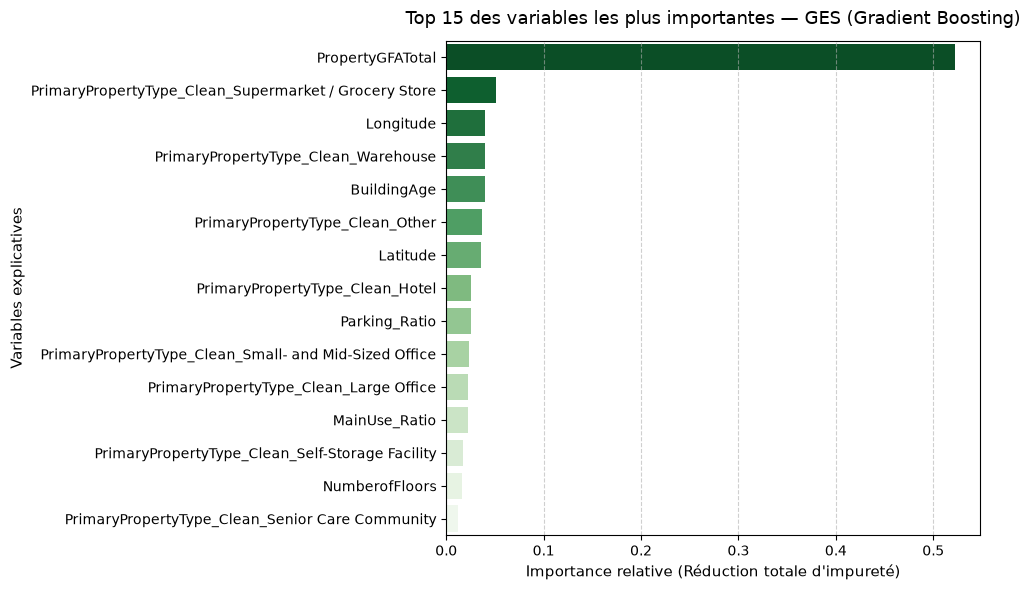

,Variable,Importance
0,PropertyGFATotal,0.5219
1,PrimaryPropertyType_Clean_Supermarket / Grocer...,0.0509
2,Longitude,0.0402
3,PrimaryPropertyType_Clean_Warehouse,0.0400
4,BuildingAge,0.0400
5,PrimaryPropertyType_Clean_Other,0.0367
6,Latitude,0.0356
7,PrimaryPropertyType_Clean_Hotel,0.0259
8,Parking_Ratio,0.0258
9,PrimaryPropertyType_Clean_Small- and Mid-Sized...,0.0229


In [47]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Extraction du modèle champion GES
best_model_ghg = grid_search_ghg.best_estimator_

# 2. Récupération des noms de variables
preprocessor_ghg = best_model_ghg.named_steps['preprocessor']
feature_names_ghg = preprocessor_ghg.get_feature_names_out()
clean_feature_names_ghg = [name.split('__')[-1] for name in feature_names_ghg]

# 3. Extraction des importances MDI
importances_ghg = best_model_ghg.named_steps['regressor'].feature_importances_

# 4. DataFrame trié
df_importance_ghg = pd.DataFrame({
    'Variable': clean_feature_names_ghg,
    'Importance': importances_ghg,
}).sort_values(by='Importance', ascending=False)

# 5. Graphique Top 15
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_importance_ghg.head(15),
    x='Importance',
    y='Variable',
    hue='Variable',
    palette='Greens_r',
    legend=False,
)
plt.title(
    'Top 15 des variables les plus importantes — GES (Gradient Boosting)',
    fontsize=13,
    pad=12,
)
plt.xlabel("Importance relative (Réduction totale d'impureté)", fontsize=11)
plt.ylabel('Variables explicatives', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 6. Affichage du Top 10
display(df_importance_ghg.head(10).round(4).reset_index(drop=True))

### Analyse et comparaison de la Feature Importance (Énergie vs GES)

#### 1. Tableau comparatif des importances relatives (MDI)

| Rang | Variable | Importance GES (MDI) | Importance Énergie (MDI) | Évolution du rôle dans le modèle |
| :---: | :--- | :---: | :---: | :--- |
| **1** | `PropertyGFATotal` | **52,19 %** | **67,28 %** | **Variable prépondérante :** capte la majorité des réductions d'impureté, bien que son poids relatif diminue de 15 points sur les GES. |
| **2** | `Supermarket / Grocery` | **5,09 %** | 4,80 % | Usage intensif (chambres froides, systèmes CVC continus). |
| **3** | `Longitude` | **4,02 %** | 2,68 % | Poids accru sur les émissions de GES par rapport à l'énergie. |
| **4** | `Warehouse` | **4,00 %** | 5,01 % | Typologie à faible intensité énergétique et faibles émissions relatives. |
| **5** | `BuildingAge` | **4,00 %** | 2,47 % | Importance renforcée sur la cible GES (+1,5 pt). |
| **6** | `Latitude` | **3,56 %** | 1,88 % | Complément spatial de localisation. |
| **7** | `Hotel` | **2,59 %** | < 1,00 % | Usage associé à des besoins thermiques et d'eau chaude sanitaire continus. |
| **8** | `Parking_Ratio` | **2,58 %** | 1,30 % | Ratio de surfaces annexes influençant l'intensité globale. |

---

#### 2. Interprétations et hypothèses métier

* **Prépondérance de la surface au sol (`PropertyGFATotal`) :**  
  La surface totale représente **67,28 %** de l'importance MDI pour l'énergie et **52,19 %** pour les émissions de GES. Elle constitue la variable de premier niveau pour calibrer l'ordre de grandeur des prédictions.
* **Différence de comportement Énergie vs GES :**  
  La baisse du poids relatif de la surface sur les GES suggère que les émissions dépendent davantage du vecteur énergétique utilisé (gaz fossile, réseau de vapeur urbain ou électricité renouvelable de Seattle) que du simple volume du bâtiment.
* **Hypothèses explicatives sur les variables secondaires (sans présomption de causalité) :**
  * **La localisation (`Longitude`, `Latitude`) :** *pourrait être corrélée* à la proximité des réseaux de distribution historiques (vapeur/gaz du centre urbain) ou à des contraintes de densité locale.
  * **L'ancienneté (`BuildingAge`) :** *peut refléter* l'évolution des normes d'isolation thermique ou une dépendance plus forte à des systèmes de chauffage plus anciens.
  * **Les typologies d'usage :** *peuvent traduire* des profils de charge très contrastés (usages continus type supermarchés/hôtels vs surfaces passives type entrepôts).